# MWE 08 - Image-based vug sensitivity with multi-realization baselines

This notebook quantifies how synthetic **spherical** and **ellipsoidal** vugs
perturb porosity and absolute permeability (`Kabs`) in a connected porous matrix.

Updated study design (requested):

- **15 baseline realizations** (no vugs), generated independently.
- At least **5 spherical vug configurations**.
- At least **5 ellipsoidal configurations stretched in the flow direction**.
- At least **5 ellipsoidal configurations stretched orthogonal to flow**.
- **Plotly pore-network visualization for every solved case**.

Important correction relative to the previous notebook revision:

- The earlier ellipsoids were effectively stretched orthogonal to flow.
- This notebook now includes both orientation families explicitly.

Assumptions to keep in mind:

- Voxel size is fixed at `10 um` (synthetic digital rock resolution).
- One centered vug per realization is used to isolate shape/size effects.
- Permeability is evaluated along one axis (`x`).
- Synthetic grayscale contrast/noise is simplified and may not match real CT artifacts.



In [44]:
from __future__ import annotations

import os
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

try:
    from tqdm.auto import tqdm as _tqdm
except Exception:  # pragma: no cover - optional dependency in notebook runtime
    _tqdm = None

from voids.geom import characteristic_size
from voids.graph.metrics import coordination_numbers
from voids.physics.petrophysics import absolute_porosity, effective_porosity
from voids.physics.singlephase import (
    FluidSinglePhase,
    PressureBC,
    SinglePhaseOptions,
    solve,
)
from voids.visualization import plot_network_plotly
from voids.generators import (
    build_image_vug_radii_3d,
    equivalent_radius_3d,
    generate_connected_matrix,
    insert_ellipsoidal_vug,
    insert_spherical_vug,
    make_synthetic_grayscale,
)
from voids.image import binarize_grayscale_volume, has_spanning_cluster
from voids.image import extract_spanning_pore_network


def iter_progress(
    iterable,
    *,
    desc: str | None = None,
    total: int | None = None,
    enabled: bool = True,
    leave: bool = False,
):
    """Wrap iterables with tqdm when requested and available."""

    if not enabled or _tqdm is None:
        return iterable
    return _tqdm(
        iterable,
        desc=desc,
        total=total,
        dynamic_ncols=True,
        leave=leave,
    )

In [45]:
# Study controls
VOXEL_SIZE_M = 10.0e-6  # 10 um
SHAPE = (60, 60, 60)
FLOW_AXIS = "x"
FLOW_AXIS_INDEX = {"x": 0, "y": 1, "z": 2}[FLOW_AXIS]

N_BASELINES = 30
TARGET_MATRIX_POROSITY = 0.15
BLOBINESS = 1.8
BASE_SEED = 20260305
MAX_MATRIX_TRIES = 120

# >= 5 spherical configurations
SPHERE_RADII_VOX = [4, 6, 8, 10, 12]

# Ellipsoid shape controls (volume-matched to spherical configs).
ELLIPSOID_MATCH_ASPECT = 1.8  # major/minor ratio
ELLIPSOID_INTEGER_SEARCH_WINDOW = 8

GRAYSCALE_VOID_MEAN = 65.0
GRAYSCALE_SOLID_MEAN = 185.0
GRAYSCALE_NOISE_STD = 8.0

PLOTLY_MAX_THROATS = 1500
PLOTLY_LAYOUT = {"width": 900, "height": 650}
# Disable screen-space size clipping to preserve full relative pore/throat size range.
PLOTLY_SIZE_LIMITS = (None, None)
USE_TQDM = os.environ.get("VOIDS_DISABLE_TQDM", "0") != "1"

# Optional fast mode for development smoke checks only
SMOKE_MODE = os.environ.get("VOIDS_VUG_SMOKE", "0") == "1"
if SMOKE_MODE:
    N_BASELINES = 1
    SPHERE_RADII_VOX = SPHERE_RADII_VOX[:1]

# Build ellipsoid configs matched to each sphere config index.
(
    ELLIPSOID_FLOW_RADII_VOX,
    ELLIPSOID_ORTH_RADII_VOX,
    volume_match_report,
) = build_image_vug_radii_3d(
    SPHERE_RADII_VOX,
    aspect=ELLIPSOID_MATCH_ASPECT,
    search_window=ELLIPSOID_INTEGER_SEARCH_WINDOW,
)

print("shape:", SHAPE, "| target matrix porosity:", TARGET_MATRIX_POROSITY)
print("voxel size:", VOXEL_SIZE_M, "m")
print("flow axis:", FLOW_AXIS)
print("n baselines:", N_BASELINES)
print("sphere configs:", len(SPHERE_RADII_VOX))
print("ellipsoid-flow configs:", len(ELLIPSOID_FLOW_RADII_VOX))
print("ellipsoid-orth configs:", len(ELLIPSOID_ORTH_RADII_VOX))

for (i, flow_err, orth_err), r, flow_r, orth_r in zip(
    volume_match_report,
    SPHERE_RADII_VOX,
    ELLIPSOID_FLOW_RADII_VOX,
    ELLIPSOID_ORTH_RADII_VOX,
):
    print(
        f"cfg{i}: sphere r={r} | flow={flow_r} ({100.0 * flow_err:+.2f}% vol) | "
        f"orth={orth_r} ({100.0 * orth_err:+.2f}% vol)"
    )


def save_network_png_matplotlib(
    *,
    net,
    pore_pressure: np.ndarray,
    png_path: Path,
    title: str,
    max_throats: int = 1500,
) -> None:
    """Save a static 3D network PNG using Matplotlib as a fallback exporter."""

    coords = np.asarray(net.pore_coords, dtype=float)
    conns = np.asarray(net.throat_conns, dtype=int)

    if conns.shape[0] > max_throats:
        sample_idx = np.linspace(0, conns.shape[0] - 1, max_throats, dtype=int)
        conns_plot = conns[sample_idx]
    else:
        conns_plot = conns

    fig = plt.figure(figsize=(8, 6))
    ax = fig.add_subplot(111, projection="3d")
    ax.set_title(title)

    for i, j in conns_plot:
        ax.plot(
            [coords[i, 0], coords[j, 0]],
            [coords[i, 1], coords[j, 1]],
            [coords[i, 2], coords[j, 2]],
            color="0.45",
            alpha=0.18,
            linewidth=0.4,
        )

    scatter = ax.scatter(
        coords[:, 0],
        coords[:, 1],
        coords[:, 2],
        c=np.asarray(pore_pressure, dtype=float),
        s=8,
        cmap="viridis",
        alpha=0.9,
    )
    ax.set_xlabel("x")
    ax.set_ylabel("y")
    ax.set_zlabel("z")
    fig.colorbar(scatter, ax=ax, shrink=0.7, pad=0.08, label="Pressure [Pa]")
    fig.tight_layout()
    fig.savefig(png_path, dpi=220, bbox_inches="tight")
    plt.close(fig)


def evaluate_case(
    *,
    baseline_id: int,
    case_name: str,
    family: str,
    orientation: str,
    config_index: int,
    radii_vox: tuple[int, int, int],
    binary_void: np.ndarray,
    baseline_void: np.ndarray,
    case_seed: int,
    baseline_kabs: float | None,
) -> tuple[dict[str, float | int | str], dict[str, object]]:
    """Run binarization -> extraction -> solve, then create Plotly network view."""

    added_void_vox = int(np.count_nonzero(binary_void & ~baseline_void))

    gray = make_synthetic_grayscale(
        binary_void,
        seed=case_seed,
        void_mean=GRAYSCALE_VOID_MEAN,
        solid_mean=GRAYSCALE_SOLID_MEAN,
        noise_std=GRAYSCALE_NOISE_STD,
    )
    segmented, threshold = binarize_grayscale_volume(
        gray,
        method="otsu",
        void_phase="dark",
    )

    extract = extract_spanning_pore_network(
        segmented.astype(int),
        voxel_size=VOXEL_SIZE_M,
        flow_axis=FLOW_AXIS,
        length_unit="m",
        provenance_notes={
            "study": "image_based_vug_sensitivity_multibaseline",
            "baseline_id": baseline_id,
            "case_name": case_name,
            "family": family,
            "orientation": orientation,
            "config_index": config_index,
            "radii_vox": list(radii_vox),
            "threshold_otsu": threshold,
            "case_seed": case_seed,
        },
    )
    net = extract.net

    bc = PressureBC(
        f"inlet_{FLOW_AXIS}min",
        f"outlet_{FLOW_AXIS}max",
        pin=2.0e5,
        pout=1.0e5,
    )
    res = solve(
        net,
        fluid=FluidSinglePhase(viscosity=1.0e-3),
        bc=bc,
        axis=FLOW_AXIS,
        options=SinglePhaseOptions(
            conductance_model="valvatne_blunt_baseline", solver="direct"
        ),
    )

    pore_size_m, pore_size_field = characteristic_size(
        net.pore, expected_shape=(net.Np,)
    )
    coordination = coordination_numbers(net)
    kabs = float(res.permeability[FLOW_AXIS])
    k_ratio = 1.0 if baseline_kabs is None else (kabs / baseline_kabs)

    fig = plot_network_plotly(
        net,
        point_scalars=res.pore_pressure,
        max_throats=PLOTLY_MAX_THROATS,
        point_size_limits=PLOTLY_SIZE_LIMITS,
        throat_size_limits=PLOTLY_SIZE_LIMITS,
        title=(
            f"B{baseline_id} | {case_name} | K{FLOW_AXIS}={kabs:.3e} m2 | "
            f"phi={float(segmented.mean()):.4f}"
        ),
        layout_kwargs=PLOTLY_LAYOUT,
    )

    row = {
        "baseline_id": baseline_id,
        "case": case_name,
        "family": family,
        "orientation": orientation,
        "config_index": config_index,
        "rx_vox": int(radii_vox[0]),
        "ry_vox": int(radii_vox[1]),
        "rz_vox": int(radii_vox[2]),
        "equivalent_radius_vox": (
            0.0 if min(radii_vox) <= 0 else equivalent_radius_3d(radii_vox)
        ),
        "added_void_vox": added_void_vox,
        "phi_image": float(segmented.mean()),
        "phi_abs": float(absolute_porosity(net)),
        f"phi_eff_{FLOW_AXIS}": float(effective_porosity(net, axis=FLOW_AXIS)),
        "K_axis_m2": kabs,
        "K_ratio_to_baseline": float(k_ratio),
        "Q_m3_s": float(res.total_flow_rate),
        "mass_balance_error": float(res.mass_balance_error),
        "Np": int(net.Np),
        "Nt": int(net.Nt),
        "mean_coordination": float(coordination.mean()),
        "mean_pore_size_um": float(1.0e6 * pore_size_m.mean()),
        "median_pore_size_um": float(1.0e6 * np.median(pore_size_m)),
        "pore_size_field": pore_size_field,
        "threshold_otsu": float(threshold),
    }
    diag = {
        "plotly": fig,
        "plotly_title": (
            f"B{baseline_id} | {case_name} | K{FLOW_AXIS}={kabs:.3e} m2 | "
            f"phi={float(segmented.mean()):.4f}"
        ),
        "net": net,
        "pore_pressure": np.asarray(res.pore_pressure, dtype=float),
        "pore_size_um": 1.0e6 * pore_size_m,
        "coordination": coordination,
        "segmented": segmented.astype(bool),
    }
    return row, diag

shape: (60, 60, 60) | target matrix porosity: 0.15
voxel size: 1e-05 m
flow axis: x
n baselines: 30
sphere configs: 5
ellipsoid-flow configs: 5
ellipsoid-orth configs: 5
cfg1: sphere r=4 | flow=(7, 3, 3) (-1.56% vol) | orth=(3, 3, 7) (-1.56% vol)
cfg2: sphere r=6 | flow=(9, 5, 5) (+4.17% vol) | orth=(5, 5, 9) (+4.17% vol)
cfg3: sphere r=8 | flow=(14, 6, 6) (-1.56% vol) | orth=(6, 6, 14) (-1.56% vol)
cfg4: sphere r=10 | flow=(16, 8, 8) (+2.40% vol) | orth=(8, 8, 16) (+2.40% vol)
cfg5: sphere r=12 | flow=(17, 10, 10) (-1.62% vol) | orth=(10, 10, 17) (-1.62% vol)


## Define vug configuration templates

Each configuration is applied to each of the baseline realizations.



In [47]:
vug_templates: list[dict[str, object]] = []

for i, r in enumerate(SPHERE_RADII_VOX, start=1):
    vug_templates.append(
        {
            "case": f"sphere_cfg{i}_r{r}",
            "family": "spherical",
            "orientation": "isotropic",
            "config_index": i,
            "radii": (r, r, r),
        }
    )

for i, radii in enumerate(ELLIPSOID_FLOW_RADII_VOX, start=1):
    vug_templates.append(
        {
            "case": f"ellipsoid_flow_cfg{i}_{radii[0]}_{radii[1]}_{radii[2]}",
            "family": "ellipsoidal",
            "orientation": "flow_stretched",
            "config_index": i,
            "radii": radii,
        }
    )

for i, radii in enumerate(ELLIPSOID_ORTH_RADII_VOX, start=1):
    vug_templates.append(
        {
            "case": f"ellipsoid_orth_cfg{i}_{radii[0]}_{radii[1]}_{radii[2]}",
            "family": "ellipsoidal",
            "orientation": "orthogonal_stretched",
            "config_index": i,
            "radii": radii,
        }
    )

print("Total vug templates:", len(vug_templates))

Total vug templates: 15


## Generate independent baseline realizations

We enforce percolation across the flow axis for each baseline.



In [48]:
baseline_images: dict[int, np.ndarray] = {}
baseline_seeds: dict[int, int] = {}

for baseline_id in iter_progress(
    range(1, N_BASELINES + 1),
    desc="Generating baseline realizations",
    total=N_BASELINES,
    enabled=USE_TQDM,
    leave=True,
):
    seed_start = BASE_SEED + 2000 * baseline_id
    baseline_void, used_seed = generate_connected_matrix(
        shape=SHAPE,
        porosity=TARGET_MATRIX_POROSITY,
        blobiness=BLOBINESS,
        axis_index=FLOW_AXIS_INDEX,
        seed_start=seed_start,
        max_tries=MAX_MATRIX_TRIES,
        show_progress=False,
        progress_desc=f"B{baseline_id}: spanning-seed search",
    )
    baseline_images[baseline_id] = baseline_void
    baseline_seeds[baseline_id] = used_seed

for baseline_id in baseline_images:
    print(
        f"baseline {baseline_id}: seed={baseline_seeds[baseline_id]}, "
        f"phi={float(baseline_images[baseline_id].mean()):.4f}, "
        f"spanning={has_spanning_cluster(baseline_images[baseline_id], FLOW_AXIS_INDEX)}"
    )

Generating baseline realizations: 100%|██████████| 30/30 [00:02<00:00, 11.40it/s]


baseline 1: seed=20262307, phi=0.1500, spanning=True
baseline 2: seed=20264305, phi=0.1500, spanning=True
baseline 3: seed=20266311, phi=0.1500, spanning=True
baseline 4: seed=20268309, phi=0.1500, spanning=True
baseline 5: seed=20270306, phi=0.1500, spanning=True
baseline 6: seed=20272309, phi=0.1500, spanning=True
baseline 7: seed=20274311, phi=0.1500, spanning=True
baseline 8: seed=20276309, phi=0.1500, spanning=True
baseline 9: seed=20278306, phi=0.1500, spanning=True
baseline 10: seed=20280306, phi=0.1500, spanning=True
baseline 11: seed=20282305, phi=0.1500, spanning=True
baseline 12: seed=20284309, phi=0.1500, spanning=True
baseline 13: seed=20286305, phi=0.1500, spanning=True
baseline 14: seed=20288306, phi=0.1500, spanning=True
baseline 15: seed=20290305, phi=0.1500, spanning=True
baseline 16: seed=20292306, phi=0.1500, spanning=True
baseline 17: seed=20294307, phi=0.1500, spanning=True
baseline 18: seed=20296305, phi=0.1500, spanning=True
baseline 19: seed=20298305, phi=0.150

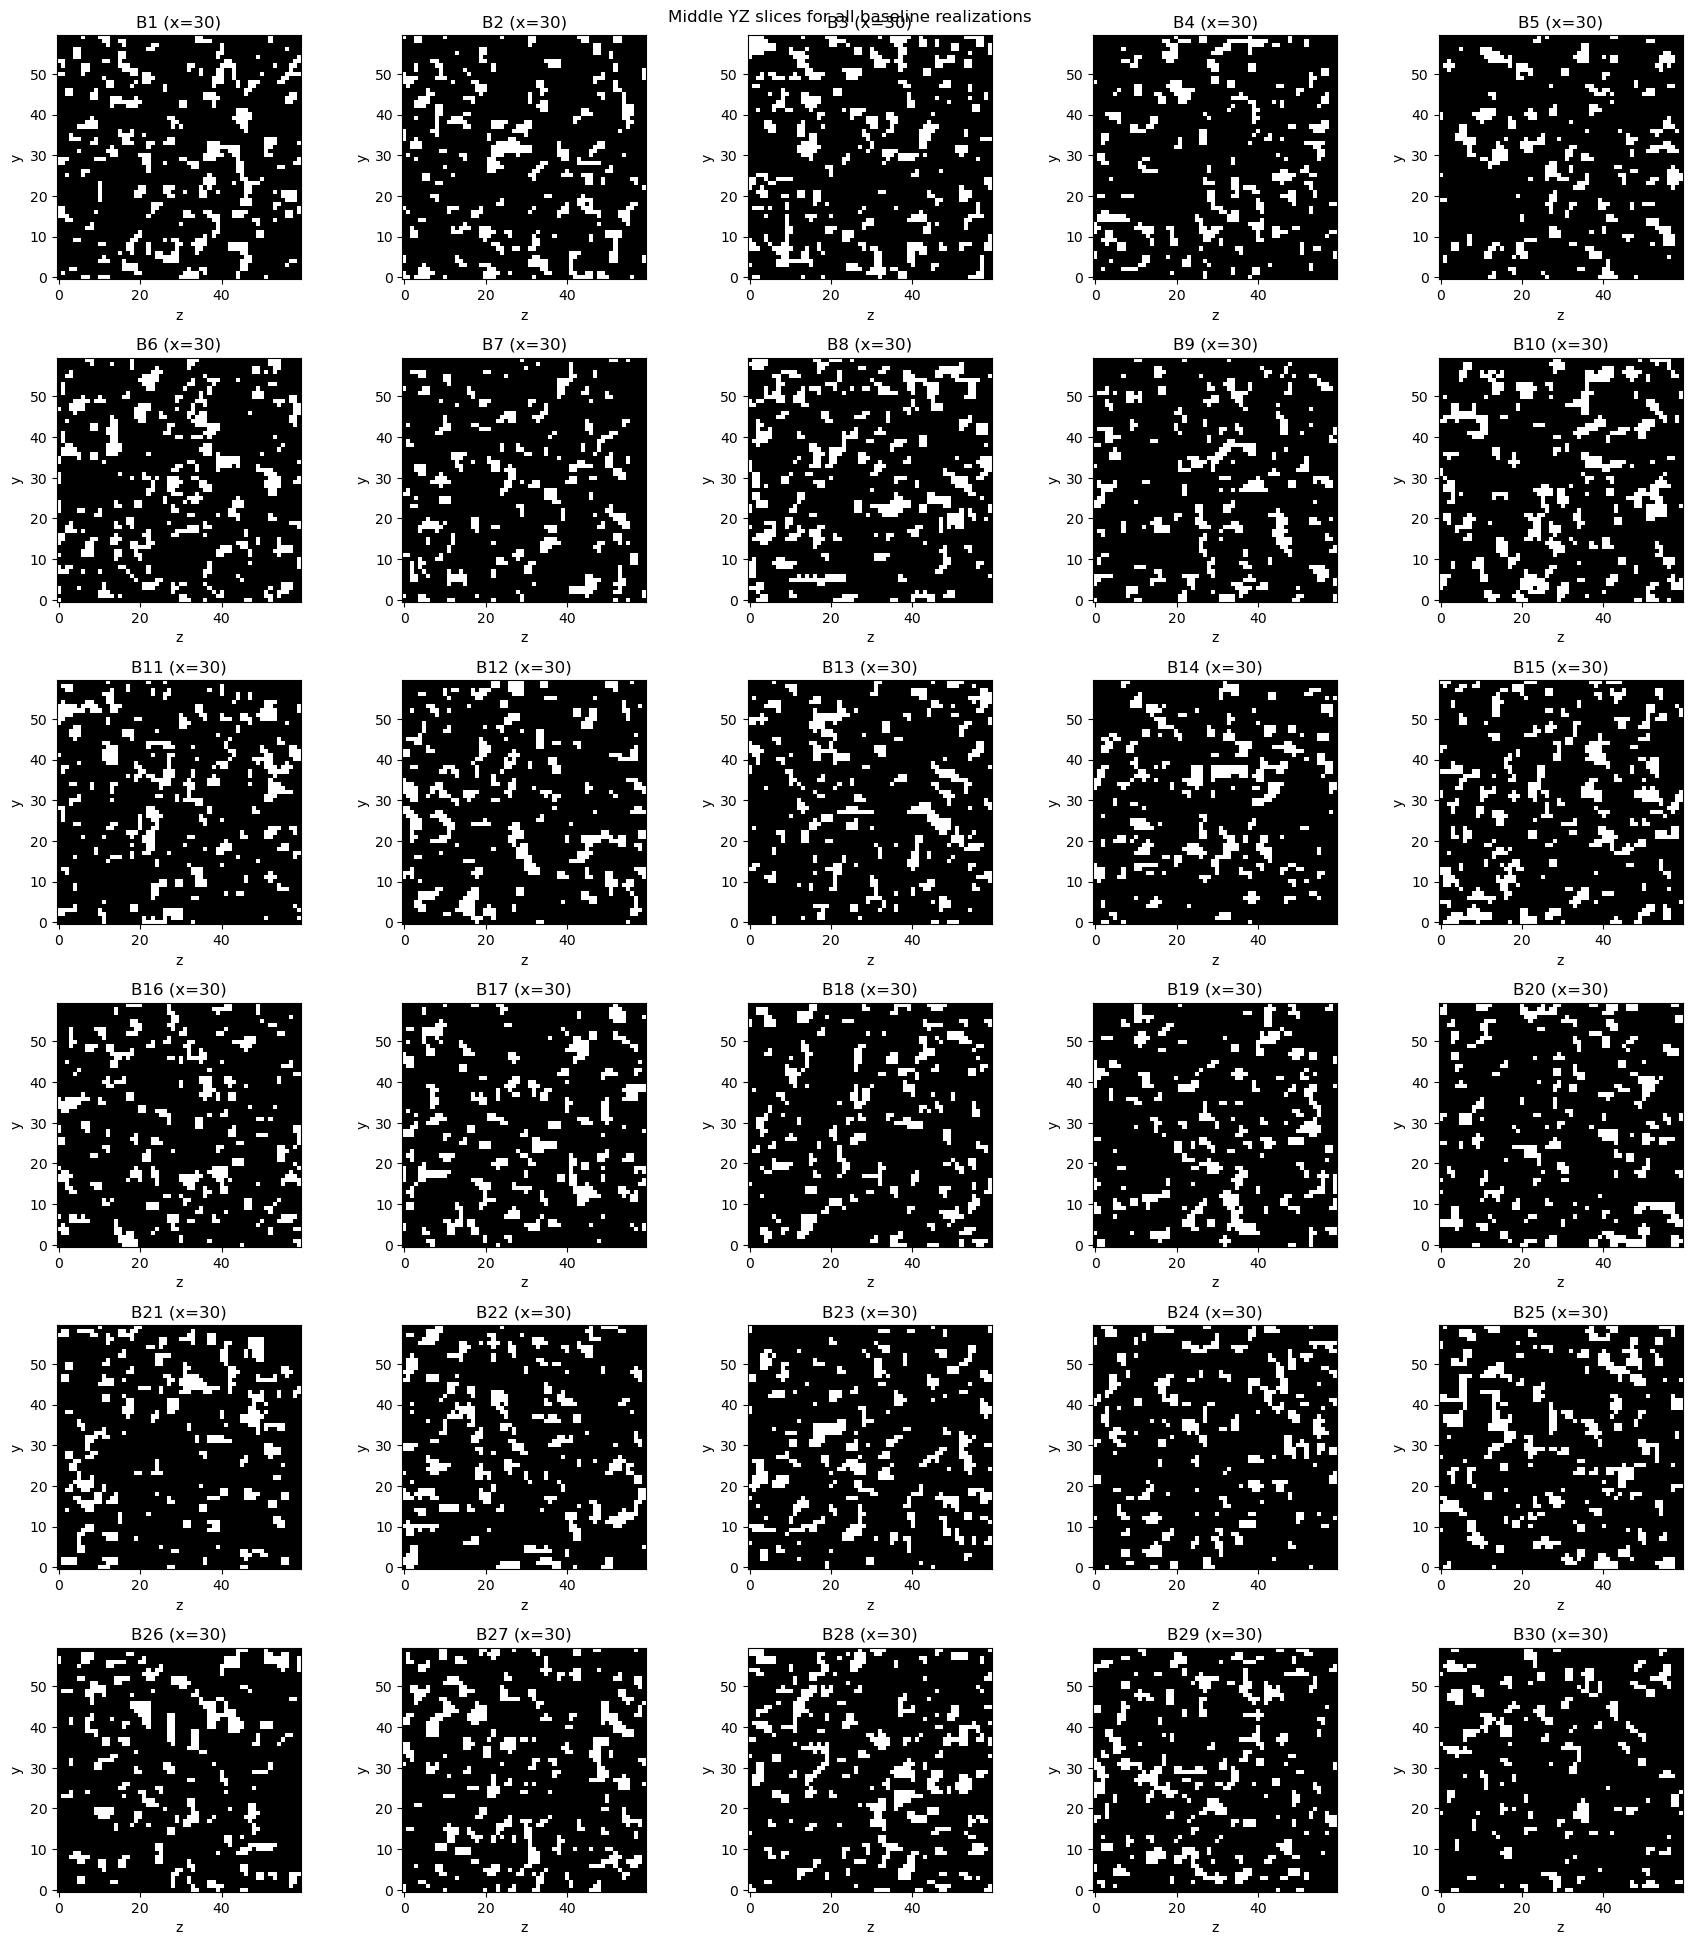

In [49]:
mid_x = SHAPE[0] // 2
ncols = min(5, N_BASELINES)
nrows = (N_BASELINES + ncols - 1) // ncols
fig, axes = plt.subplots(
    nrows, ncols, figsize=(3.5 * ncols, 3.3 * nrows), squeeze=False
)

baseline_ids = sorted(baseline_images.keys())
for idx, baseline_id in enumerate(baseline_ids):
    row = idx // ncols
    col = idx % ncols
    ax = axes[row, col]
    ax.imshow(baseline_images[baseline_id][mid_x], cmap="gray", origin="lower")
    ax.set_title(f"B{baseline_id} (x={mid_x})")
    ax.set_xlabel("z")
    ax.set_ylabel("y")

for idx in range(len(baseline_ids), nrows * ncols):
    axes[idx // ncols, idx % ncols].axis("off")

fig.suptitle("Middle YZ slices for all baseline realizations")
plt.tight_layout()
plt.show()

## Run all baseline + vug cases and solve flow

Total number of cases:

`N_BASELINES * (1 + N_spherical + N_ellipsoid_flow + N_ellipsoid_orth)`



In [50]:
all_results: list[dict[str, float | int | str]] = []
all_diagnostics: dict[str, dict[str, object]] = {}
case_void_images: dict[str, np.ndarray] = {}

HAS_DEBUG_PRINTS = False
baseline_id_iter = iter_progress(
    sorted(baseline_images.keys()),
    desc="Running baseline studies",
    total=len(baseline_images),
    enabled=USE_TQDM,
    leave=True,
)
for baseline_id in baseline_id_iter:
    baseline_void = baseline_images[baseline_id]

    # Baseline case first to define K0 for this realization
    baseline_case_name = f"B{baseline_id}_baseline"
    case_void_images[baseline_case_name] = baseline_void.copy()
    baseline_row, baseline_diag = evaluate_case(
        baseline_id=baseline_id,
        case_name=baseline_case_name,
        family="baseline",
        orientation="none",
        config_index=0,
        radii_vox=(0, 0, 0),
        binary_void=baseline_void,
        baseline_void=baseline_void,
        case_seed=BASE_SEED + 10000 + baseline_id,
        baseline_kabs=None,
    )
    baseline_kabs = float(baseline_row["K_axis_m2"])
    all_results.append(baseline_row)
    all_diagnostics[baseline_case_name] = baseline_diag

    if HAS_DEBUG_PRINTS:
        print(
            f"{baseline_case_name:>24s} | phi_image={baseline_row['phi_image']:.4f} | "
            f"K{FLOW_AXIS}={baseline_kabs:.3e} m^2"
        )

    # Vug cases for this baseline
    template_iter = iter_progress(
        list(enumerate(vug_templates, start=1)),
        desc=f"B{baseline_id}: vug configurations",
        total=len(vug_templates),
        enabled=USE_TQDM,
        leave=False,
    )
    for j, tpl in template_iter:
        case_root = str(tpl["case"])
        family = str(tpl["family"])
        orientation = str(tpl["orientation"])
        config_index = int(tpl["config_index"])
        radii = tuple(int(v) for v in tuple(tpl["radii"]))

        case_name = f"B{baseline_id}_{case_root}"
        if family == "spherical":
            case_void, _ = insert_spherical_vug(baseline_void, radius_vox=radii[0])
        else:
            case_void, _ = insert_ellipsoidal_vug(baseline_void, radii_vox=radii)
        case_void_images[case_name] = case_void.copy()

        row, diag = evaluate_case(
            baseline_id=baseline_id,
            case_name=case_name,
            family=family,
            orientation=orientation,
            config_index=config_index,
            radii_vox=radii,
            binary_void=case_void,
            baseline_void=baseline_void,
            case_seed=BASE_SEED + 20000 + 1000 * baseline_id + j,
            baseline_kabs=baseline_kabs,
        )
        all_results.append(row)
        all_diagnostics[case_name] = diag

        if HAS_DEBUG_PRINTS:
            print(
                f"{case_name:>24s} | phi_image={row['phi_image']:.4f} | "
                f"K{FLOW_AXIS}={row['K_axis_m2']:.3e} m^2 | "
                f"K/K0={row['K_ratio_to_baseline']:.3f}"
            )

print("Total solved cases:", len(all_results))

Running baseline studies: 100%|██████████| 30/30 [08:45<00:00, 17.52s/it]

Total solved cases: 480


In [51]:
header = (
    f"{'case':<36} {'family':<11} {'orientation':<20} {'cfg':>3} "
    f"{'r_eq':>7} {'phi[%]':>8} {'K[m2]':>11} {'K/K0':>7} {'Np':>5} {'Nt':>6}"
)
print(header)
print("-" * len(header))

for row in all_results:
    print(
        f"{str(row['case']):<36} {str(row['family']):<11} {str(row['orientation']):<20} "
        f"{int(row['config_index']):>3d} {float(row['equivalent_radius_vox']):>7.2f} "
        f"{100.0 * float(row['phi_image']):>8.3f} {float(row['K_axis_m2']):>11.3e} "
        f"{float(row['K_ratio_to_baseline']):>7.3f} {int(row['Np']):>5d} {int(row['Nt']):>6d}"
    )

case                                 family      orientation          cfg    r_eq   phi[%]       K[m2]    K/K0    Np     Nt
---------------------------------------------------------------------------------------------------------------------------
B1_baseline                          baseline    none                   0    0.00   15.000   4.106e-13   1.000   438    818
B1_sphere_cfg1_r4                    spherical   isotropic              1    4.00   15.106   4.208e-13   1.025   453    841
B1_sphere_cfg2_r6                    spherical   isotropic              2    6.00   15.375   4.071e-13   0.991   455    840
B1_sphere_cfg3_r8                    spherical   isotropic              3    8.00   15.821   3.970e-13   0.967   452    838
B1_sphere_cfg4_r10                   spherical   isotropic              4   10.00   16.597   4.120e-13   1.003   452    831
B1_sphere_cfg5_r12                   spherical   isotropic              5   12.00   17.787   3.955e-13   0.963   441    813
B1_ellip

## Post-vug Image Slices For All Realizations

For each baseline realization, show middle YZ slices (`x = mid_x`) for all
post-inclusion vug configurations, grouped by orientation family.




Plotting post-vug slice atlases:   0%|          | 0/30 [00:00<?, ?it/s]

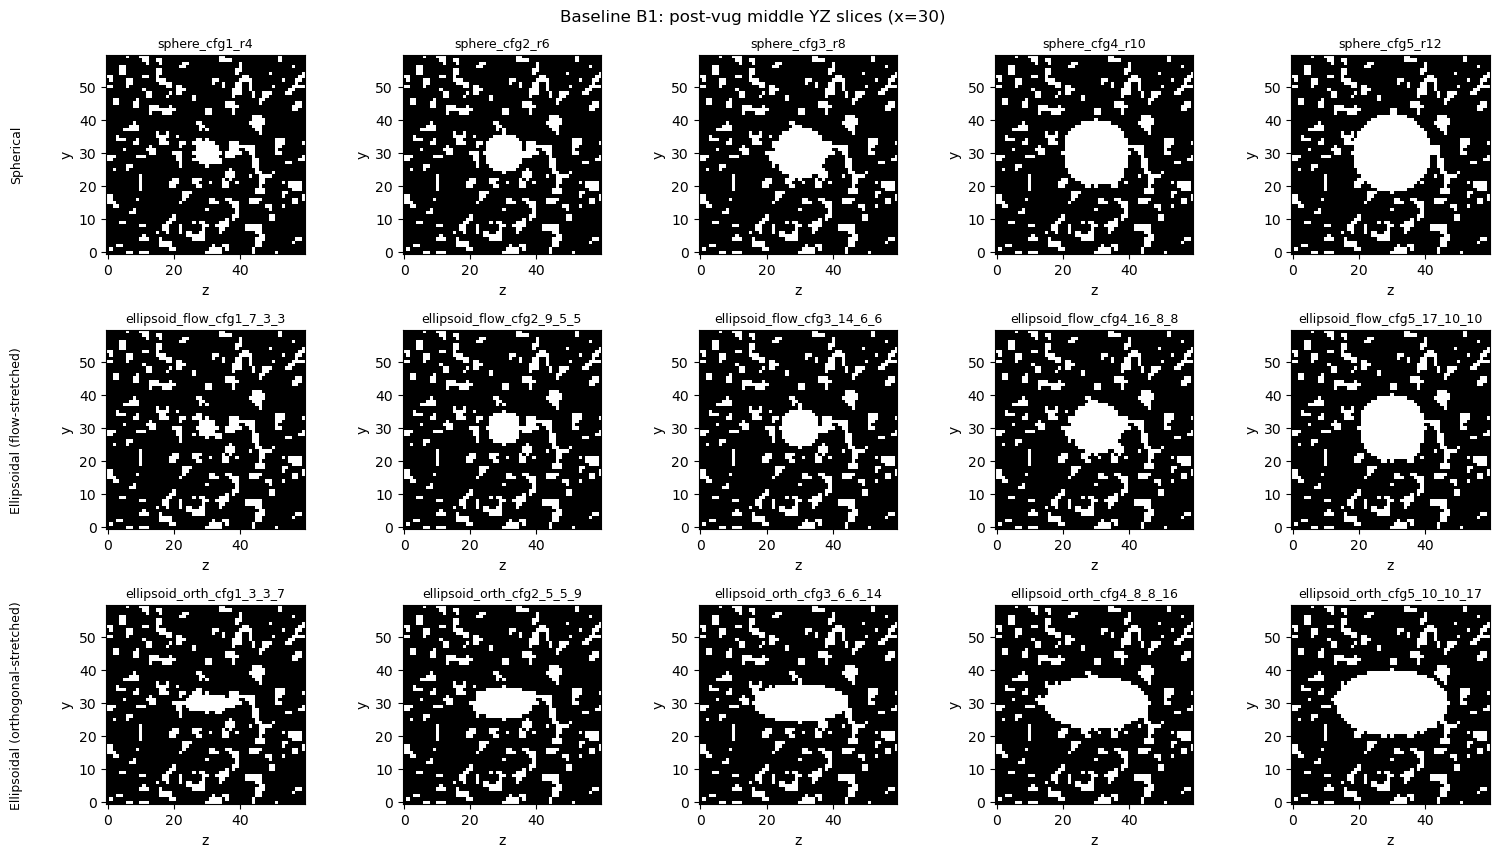

Plotting post-vug slice atlases:   3%|▎         | 1/30 [00:00<00:12,  2.40it/s]

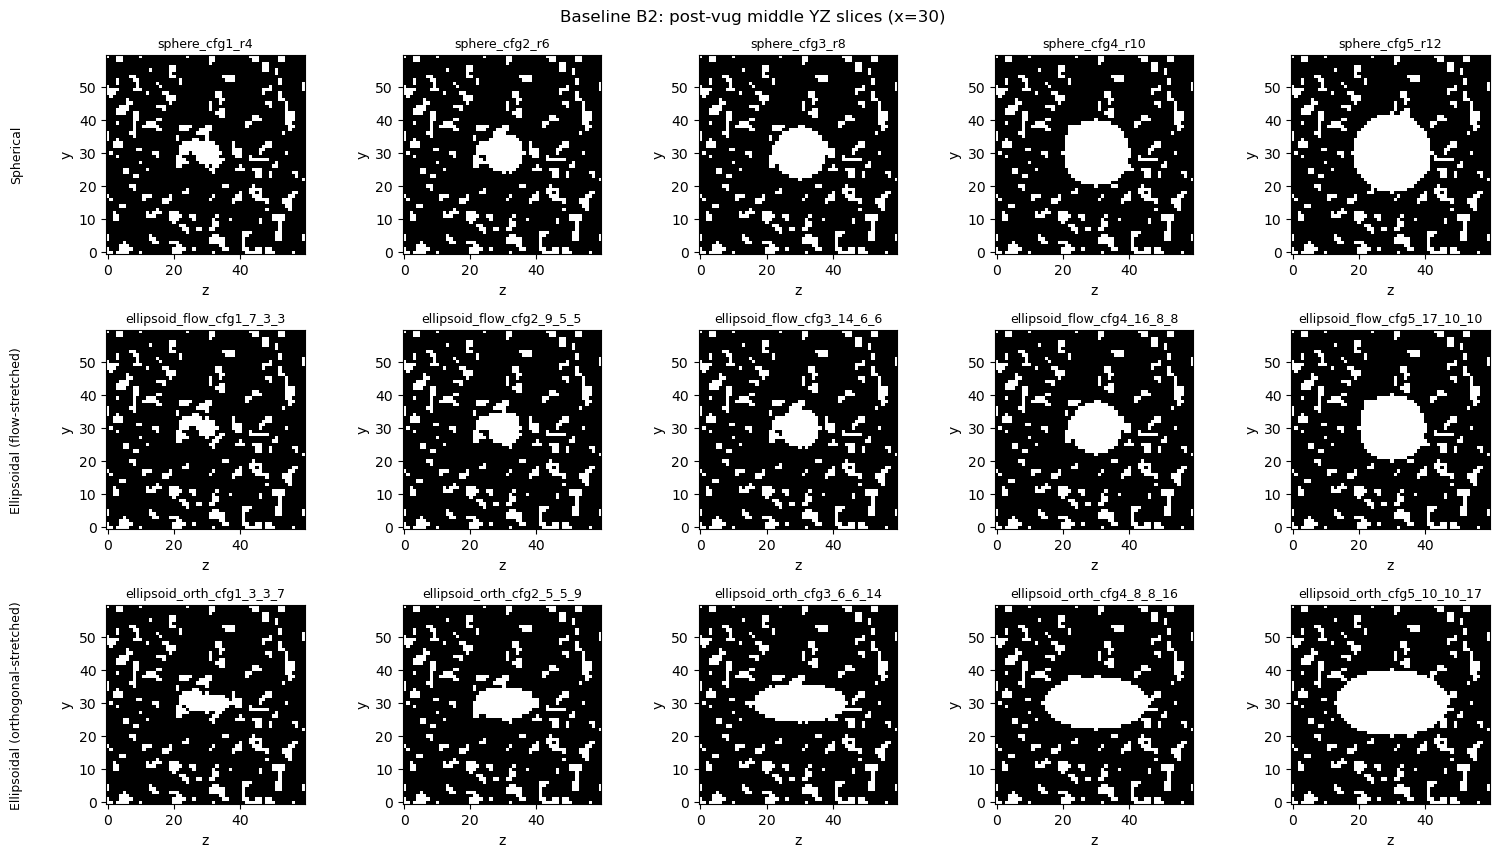

Plotting post-vug slice atlases:   7%|▋         | 2/30 [00:00<00:11,  2.48it/s]

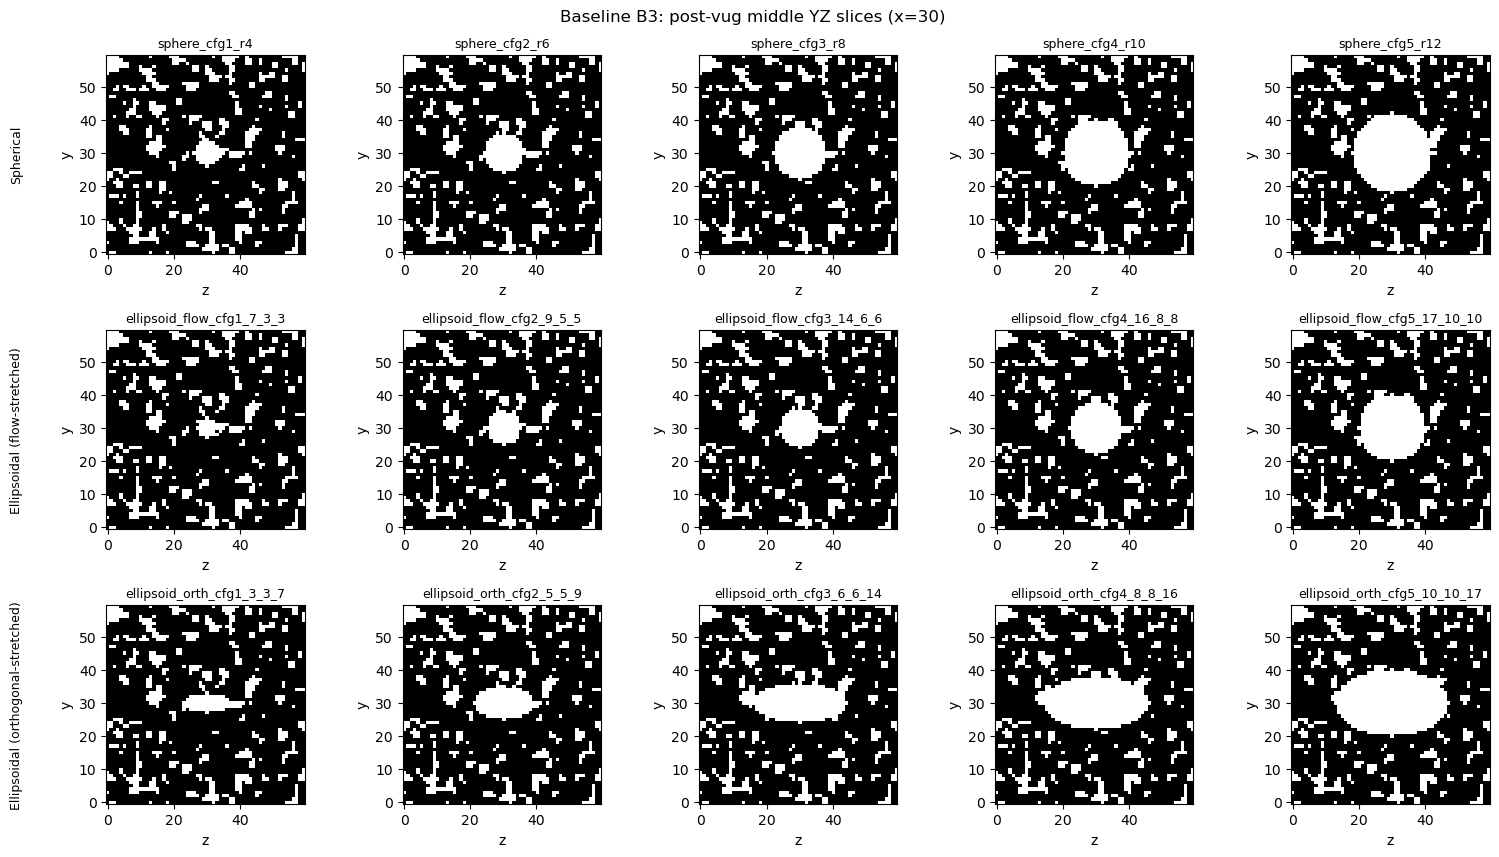

Plotting post-vug slice atlases:  10%|█         | 3/30 [00:01<00:10,  2.53it/s]

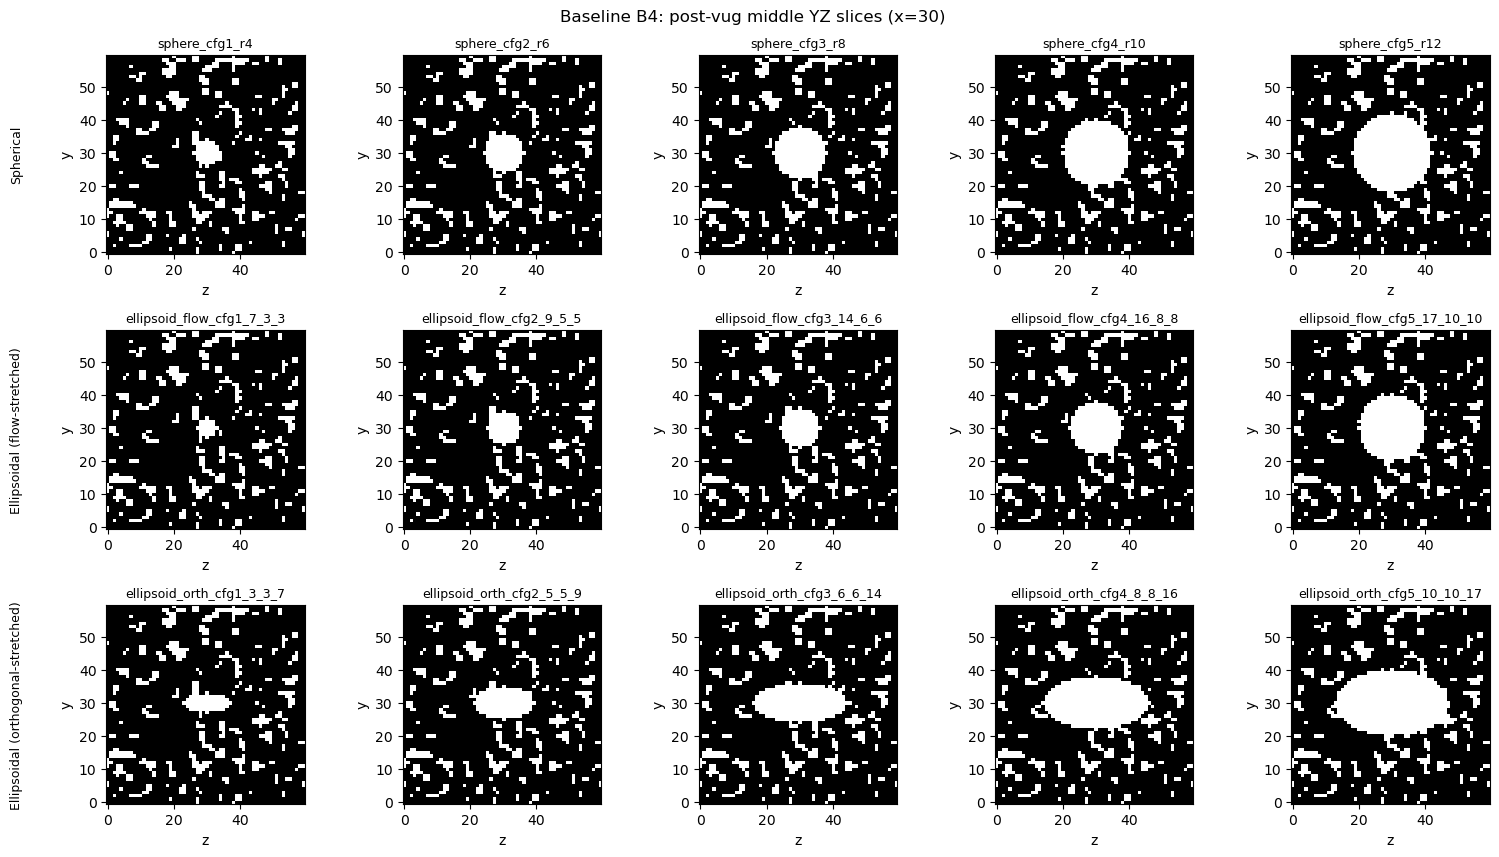

Plotting post-vug slice atlases:  13%|█▎        | 4/30 [00:01<00:10,  2.56it/s]

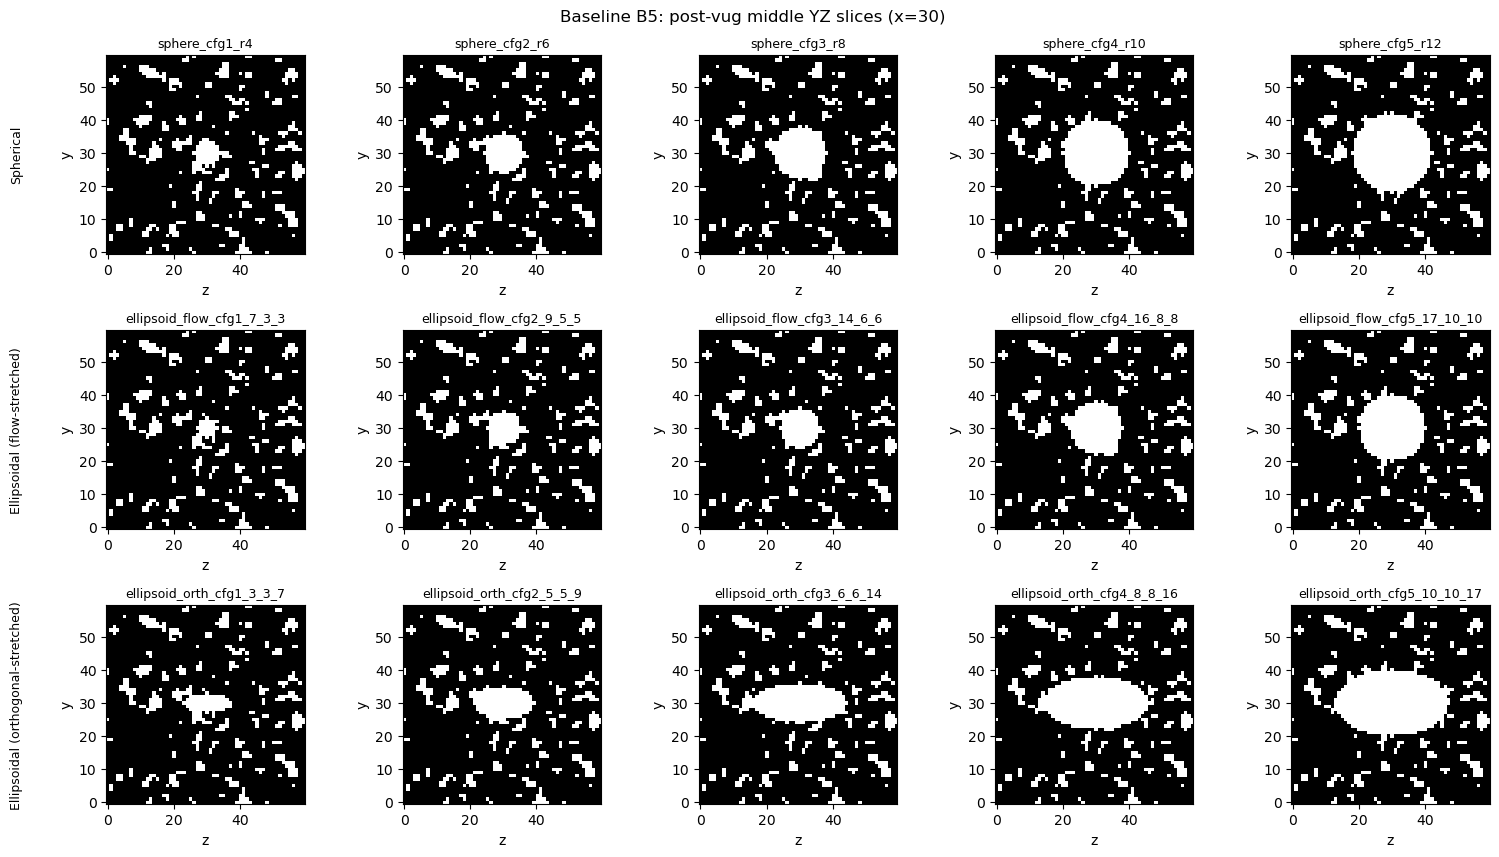

Plotting post-vug slice atlases:  17%|█▋        | 5/30 [00:01<00:09,  2.57it/s]

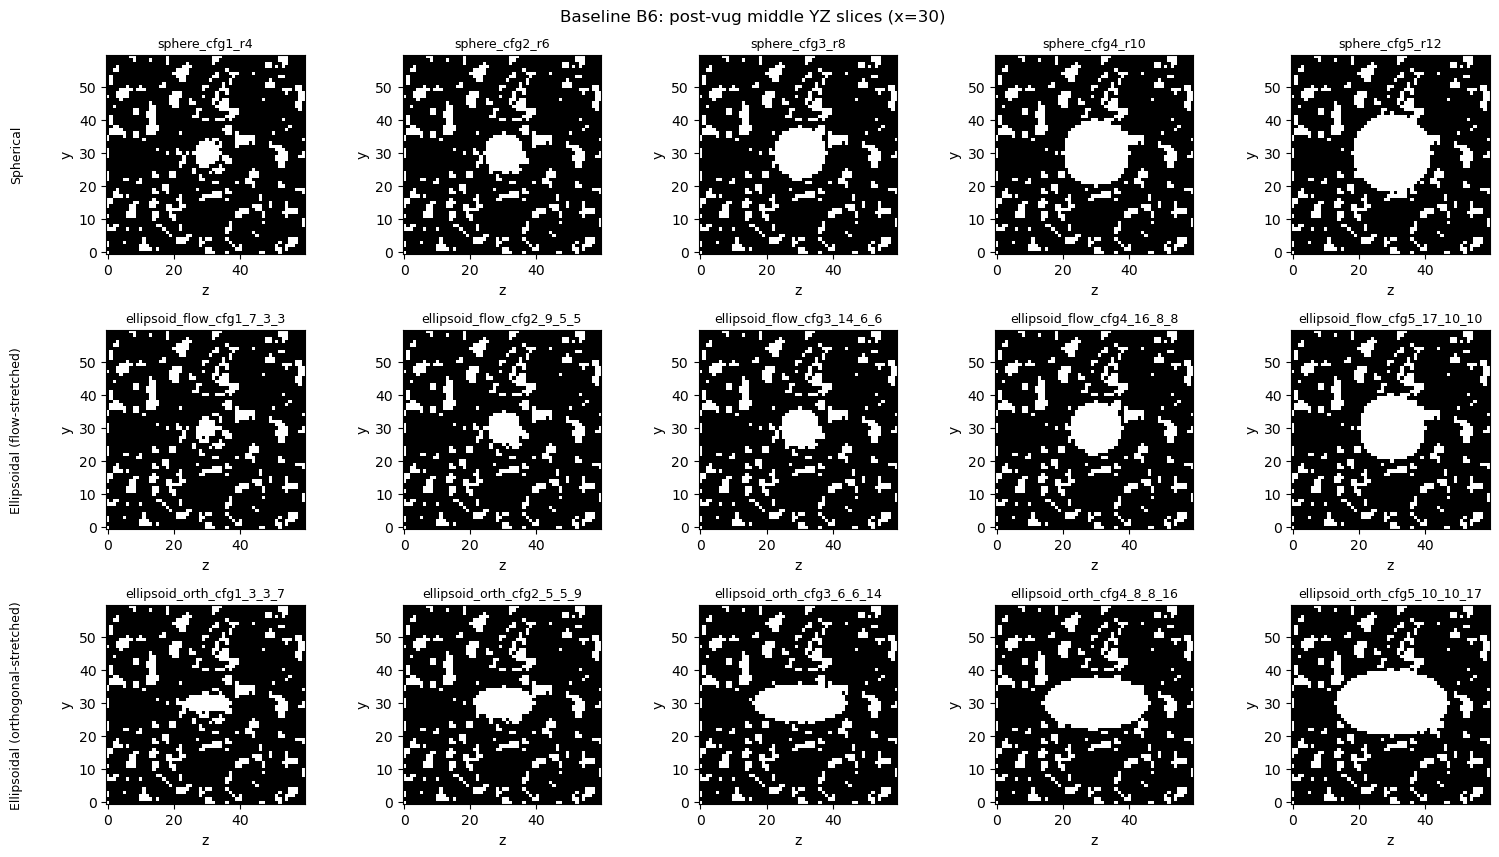

Plotting post-vug slice atlases:  20%|██        | 6/30 [00:02<00:09,  2.57it/s]

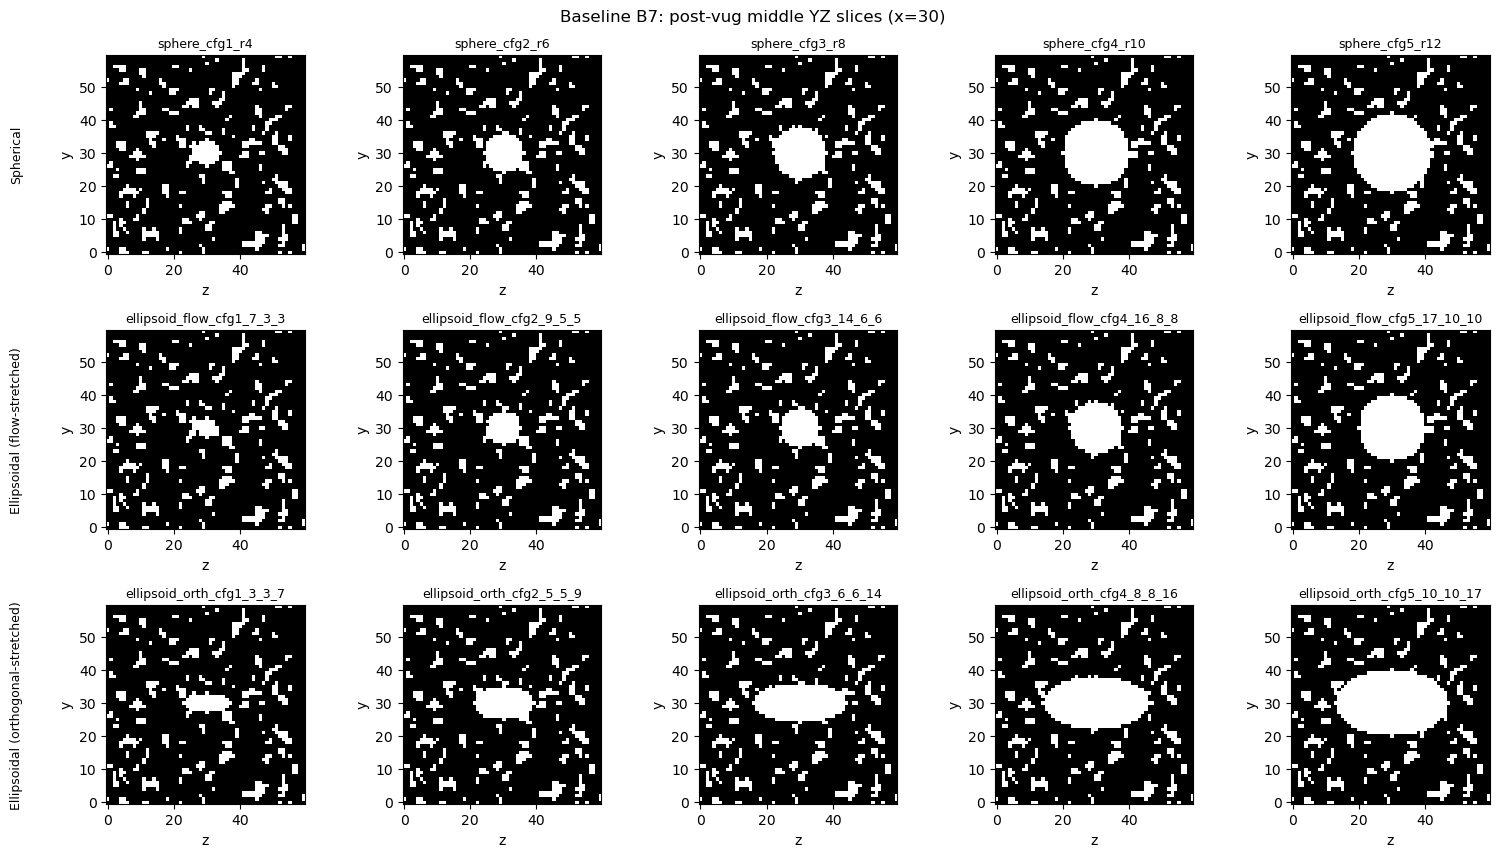

Plotting post-vug slice atlases:  23%|██▎       | 7/30 [00:02<00:08,  2.58it/s]

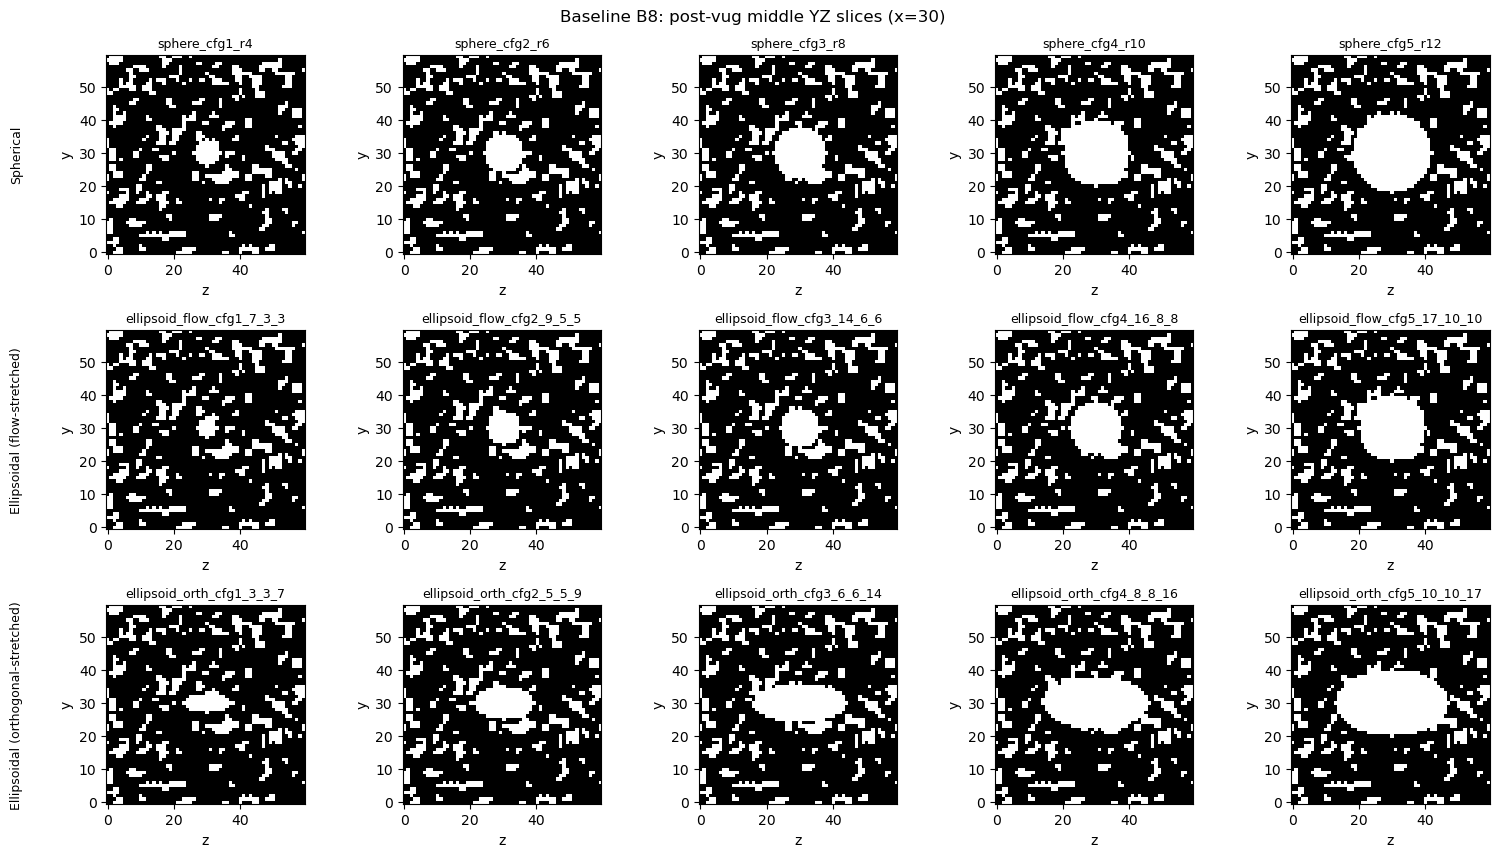

Plotting post-vug slice atlases:  27%|██▋       | 8/30 [00:03<00:08,  2.56it/s]

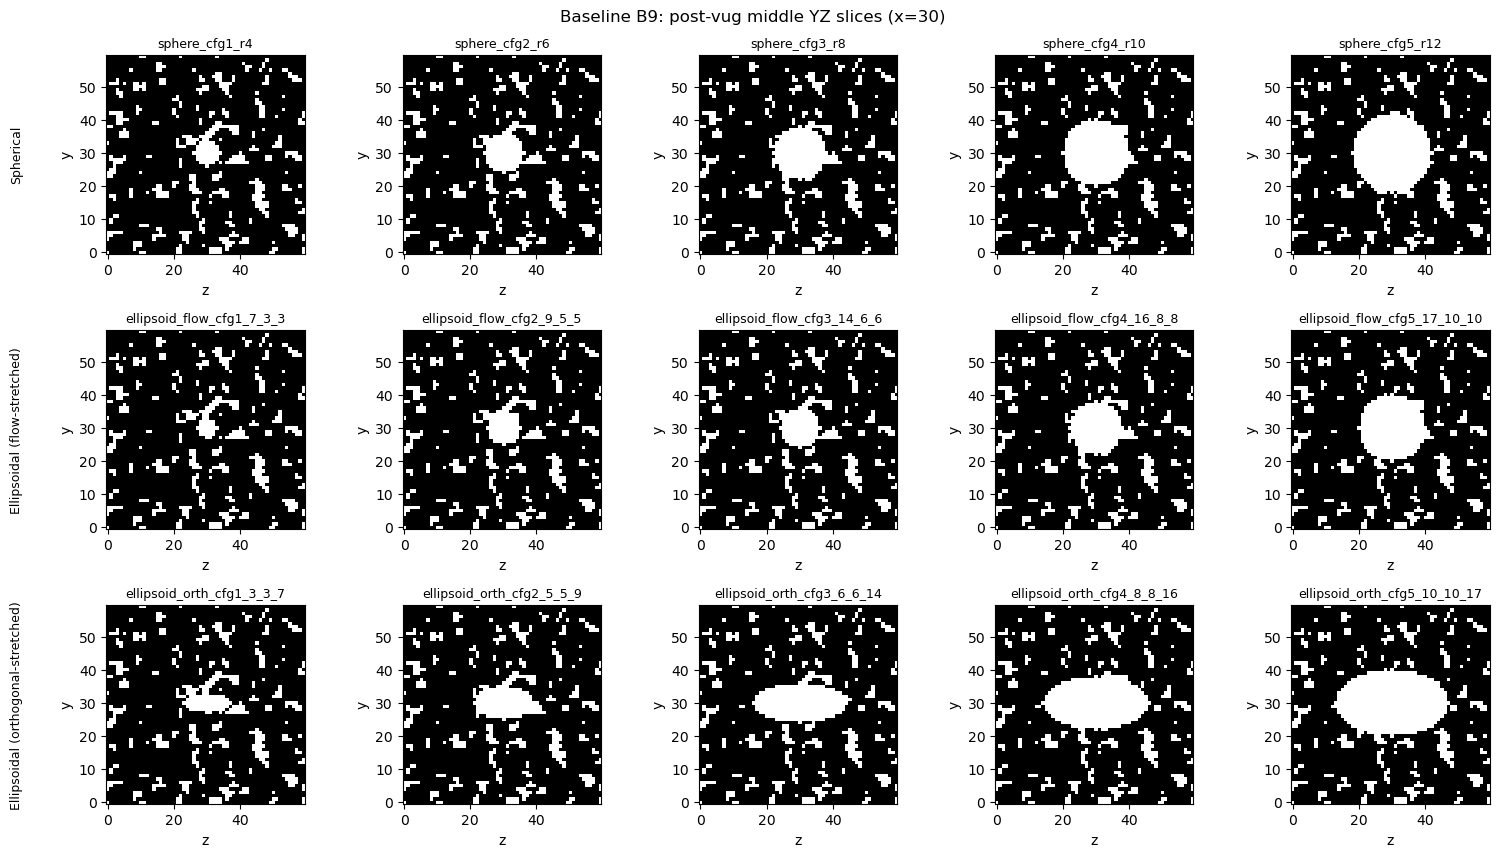

Plotting post-vug slice atlases:  30%|███       | 9/30 [00:03<00:08,  2.55it/s]

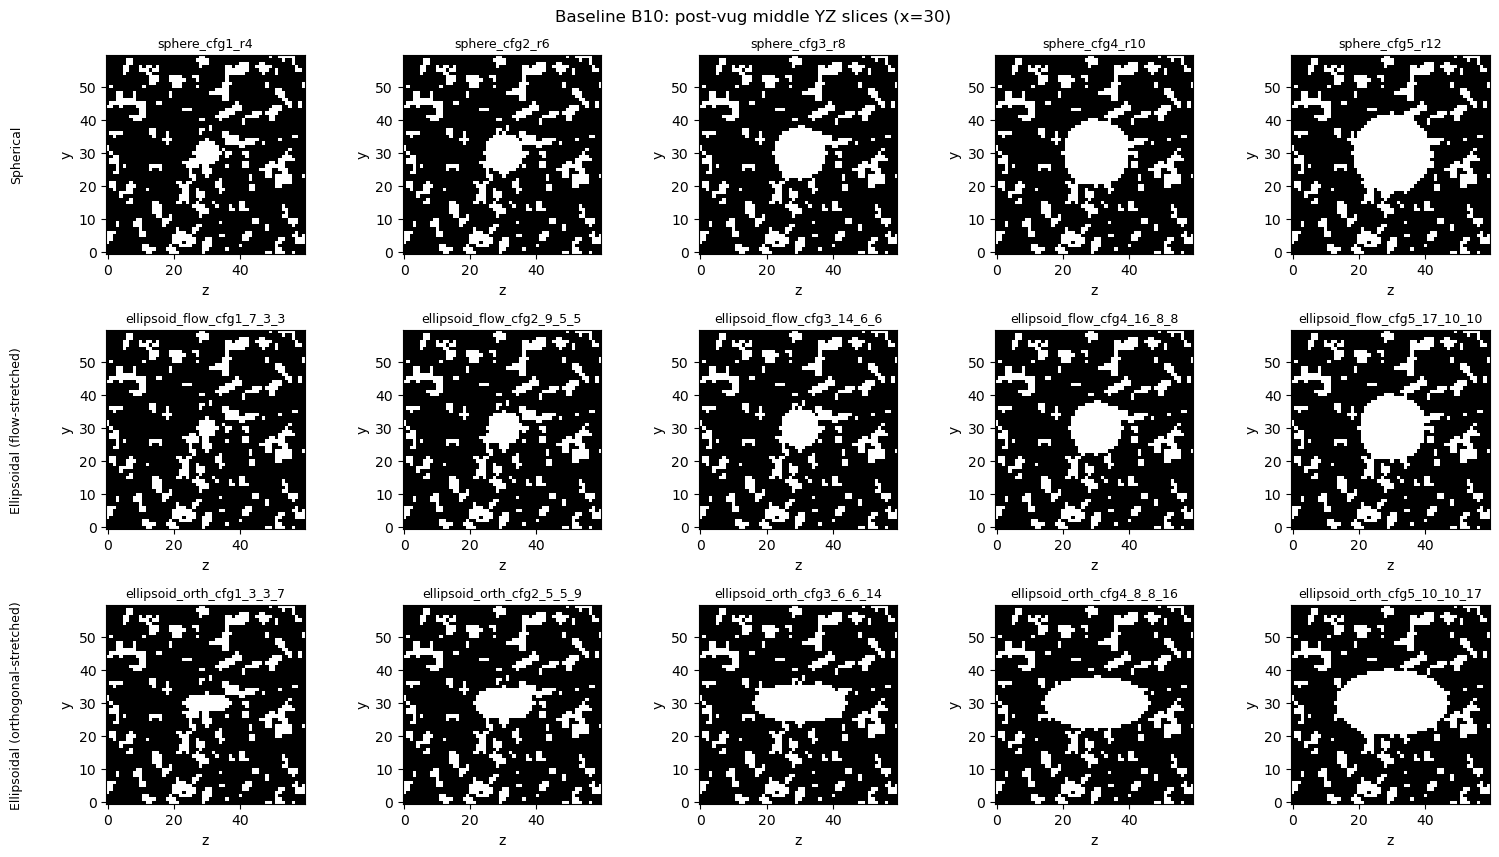

Plotting post-vug slice atlases:  33%|███▎      | 10/30 [00:03<00:07,  2.55it/s]

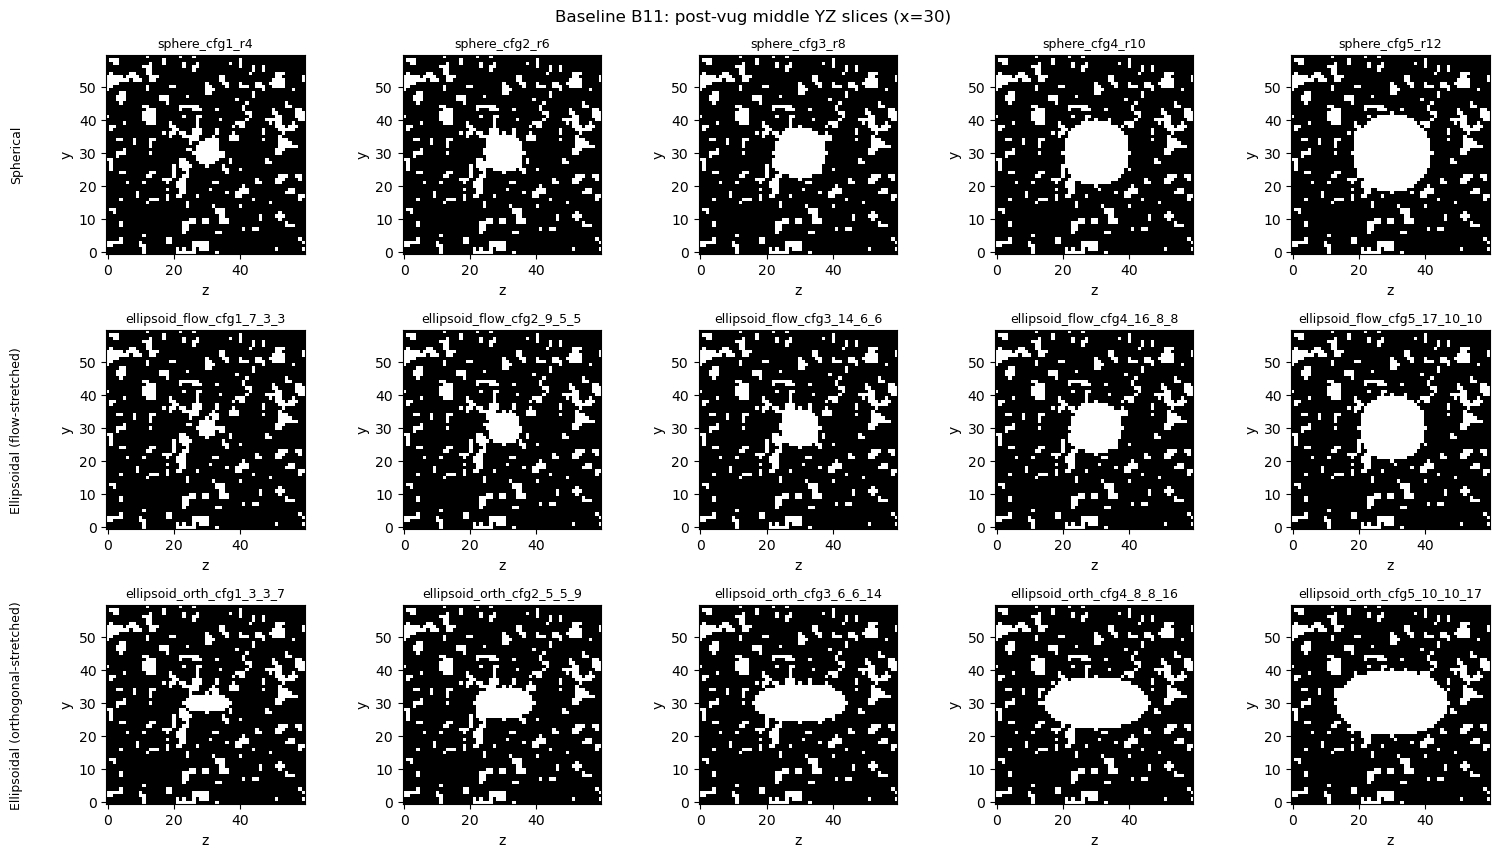

Plotting post-vug slice atlases:  37%|███▋      | 11/30 [00:04<00:07,  2.55it/s]

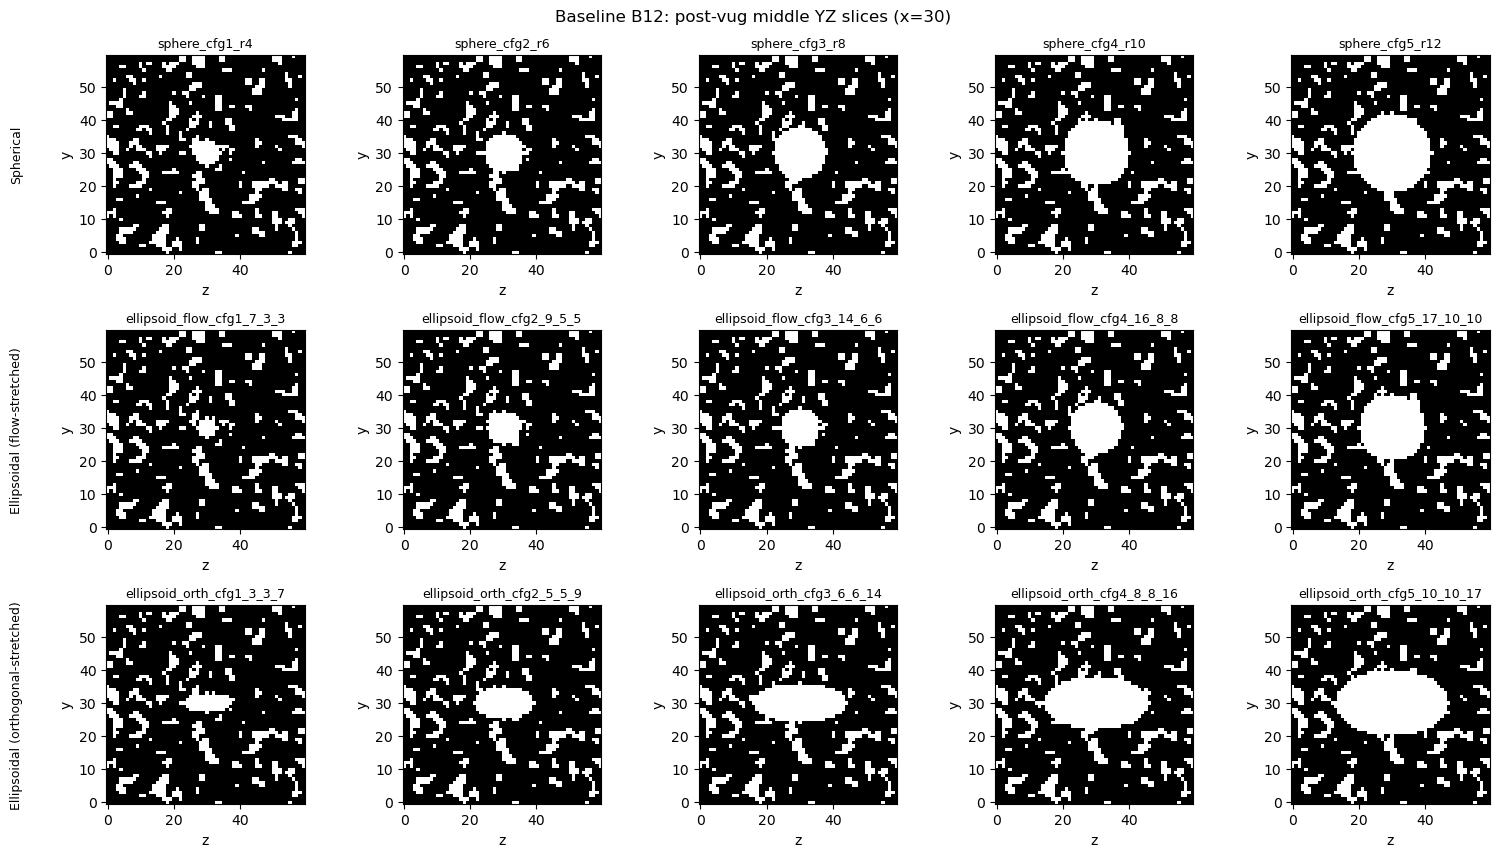

Plotting post-vug slice atlases:  40%|████      | 12/30 [00:04<00:07,  2.56it/s]

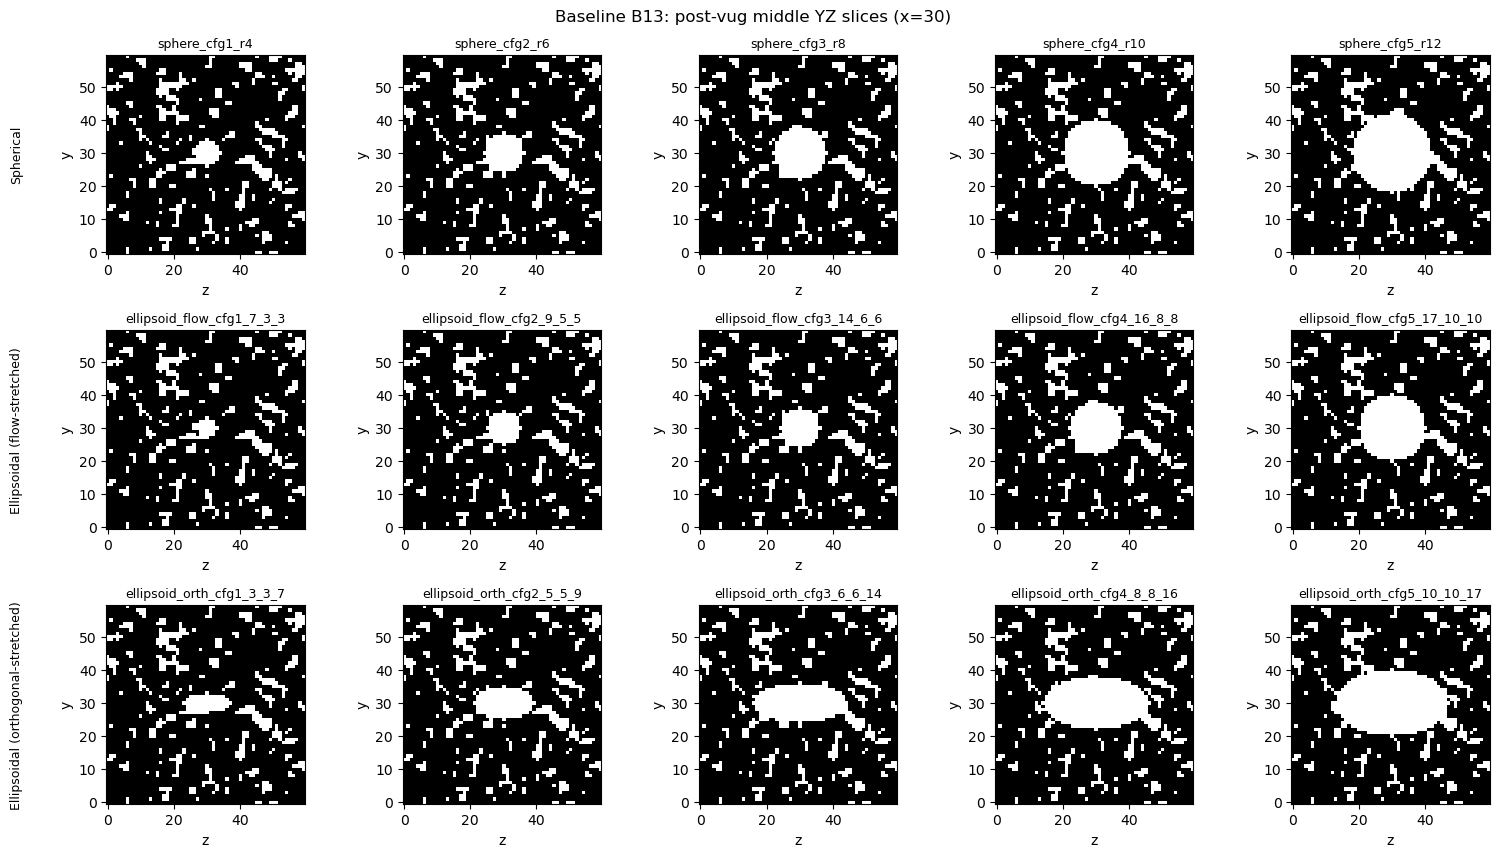

Plotting post-vug slice atlases:  43%|████▎     | 13/30 [00:05<00:06,  2.56it/s]

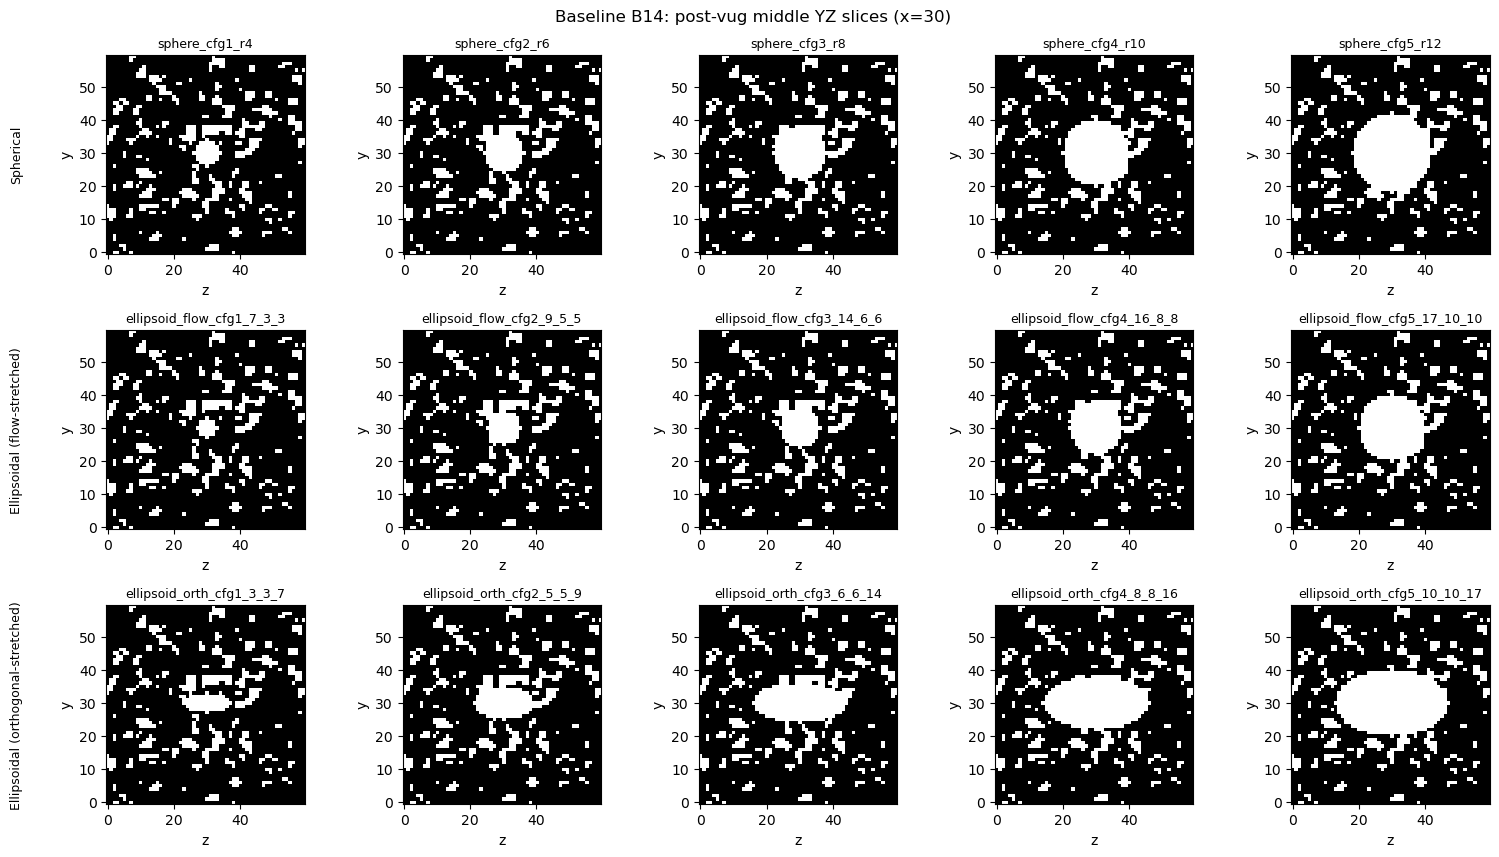

Plotting post-vug slice atlases:  47%|████▋     | 14/30 [00:05<00:06,  2.57it/s]

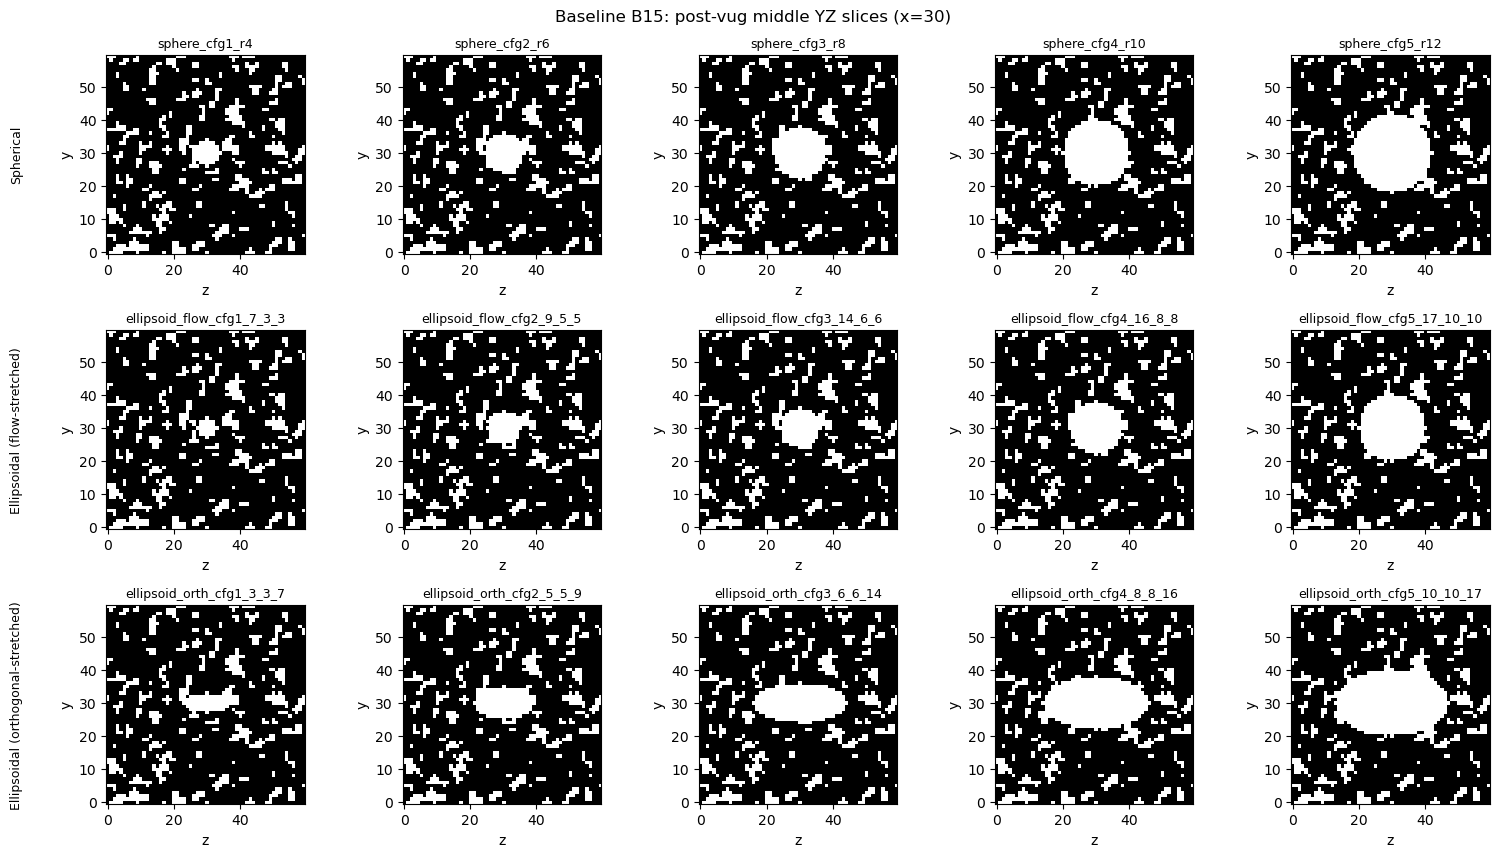

Plotting post-vug slice atlases:  50%|█████     | 15/30 [00:05<00:05,  2.57it/s]

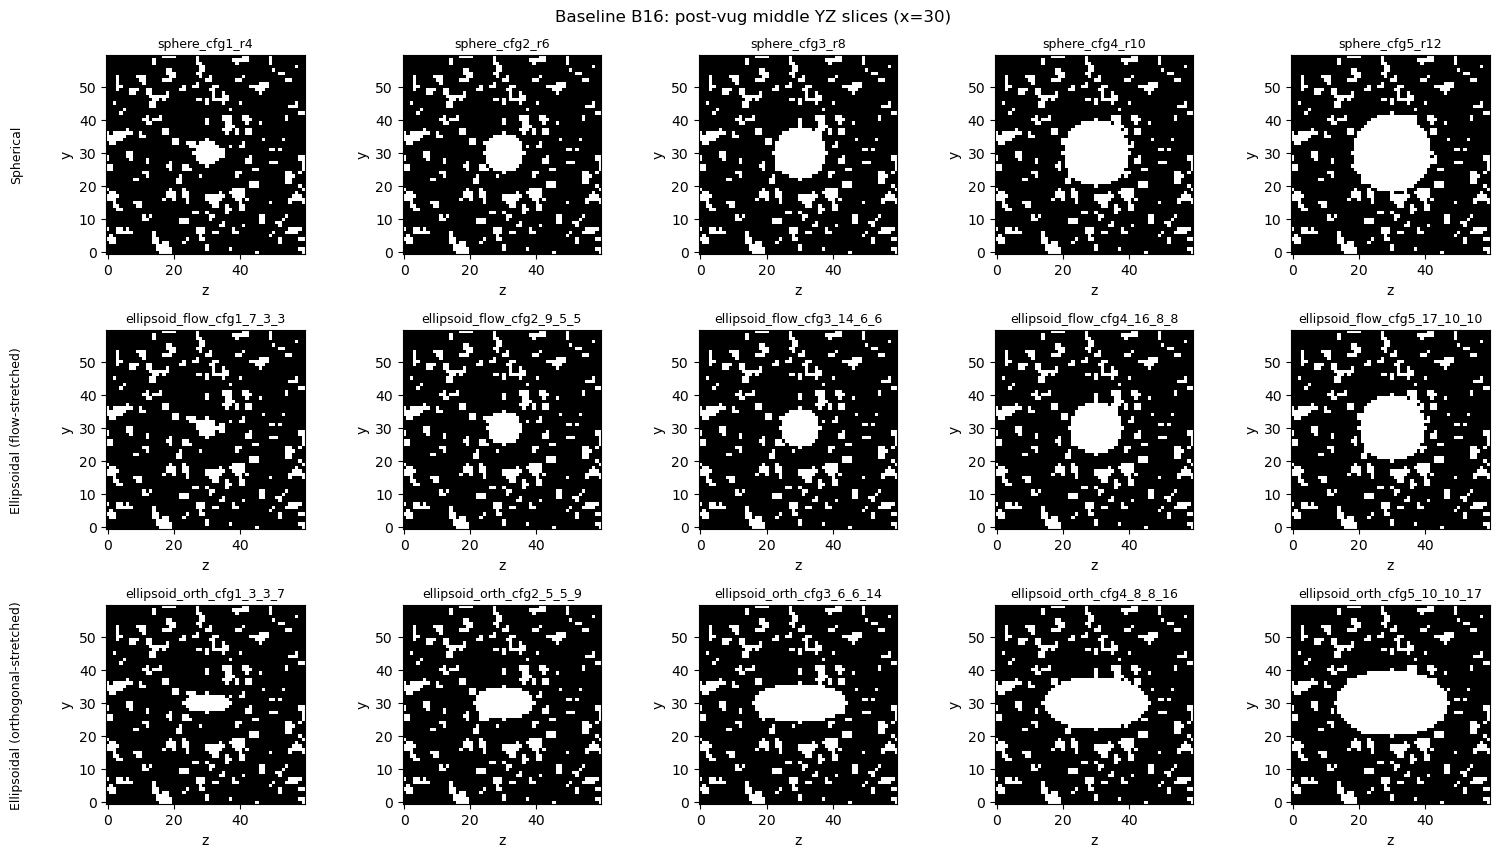

Plotting post-vug slice atlases:  53%|█████▎    | 16/30 [00:06<00:05,  2.57it/s]

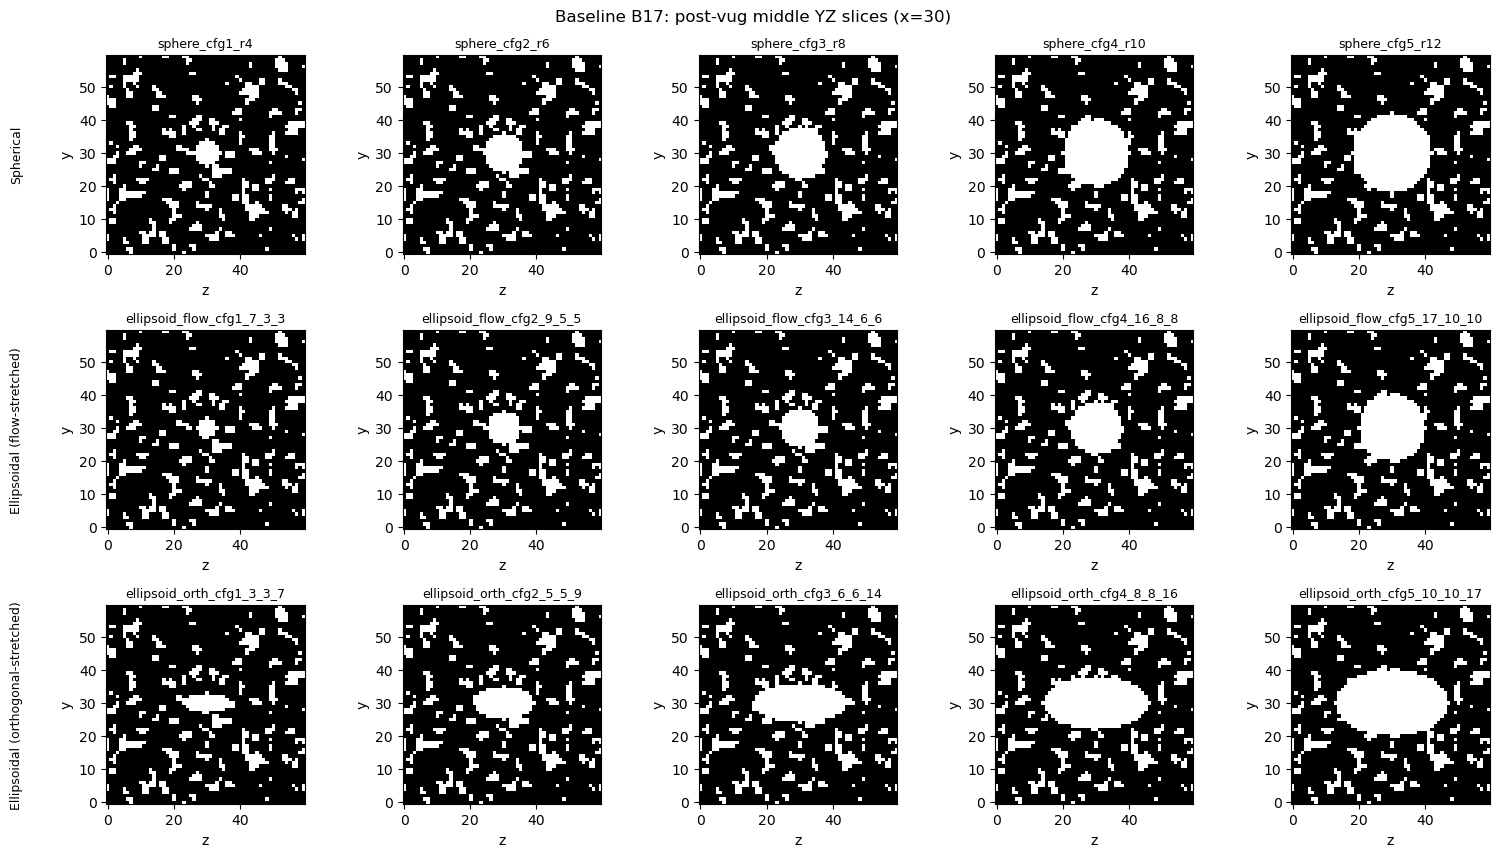

Plotting post-vug slice atlases:  57%|█████▋    | 17/30 [00:06<00:05,  2.57it/s]

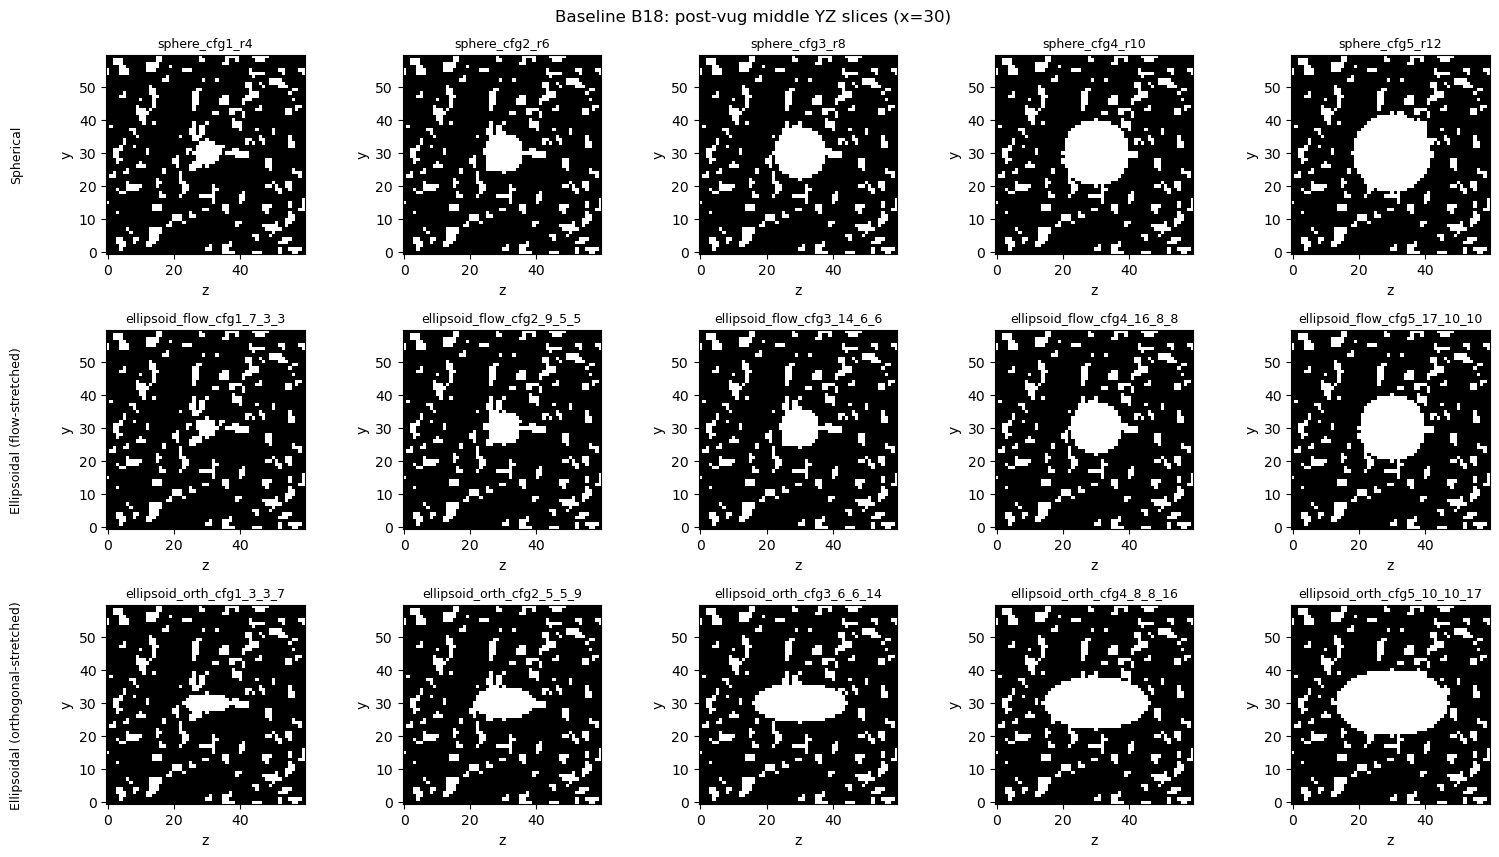

Plotting post-vug slice atlases:  60%|██████    | 18/30 [00:07<00:04,  2.56it/s]

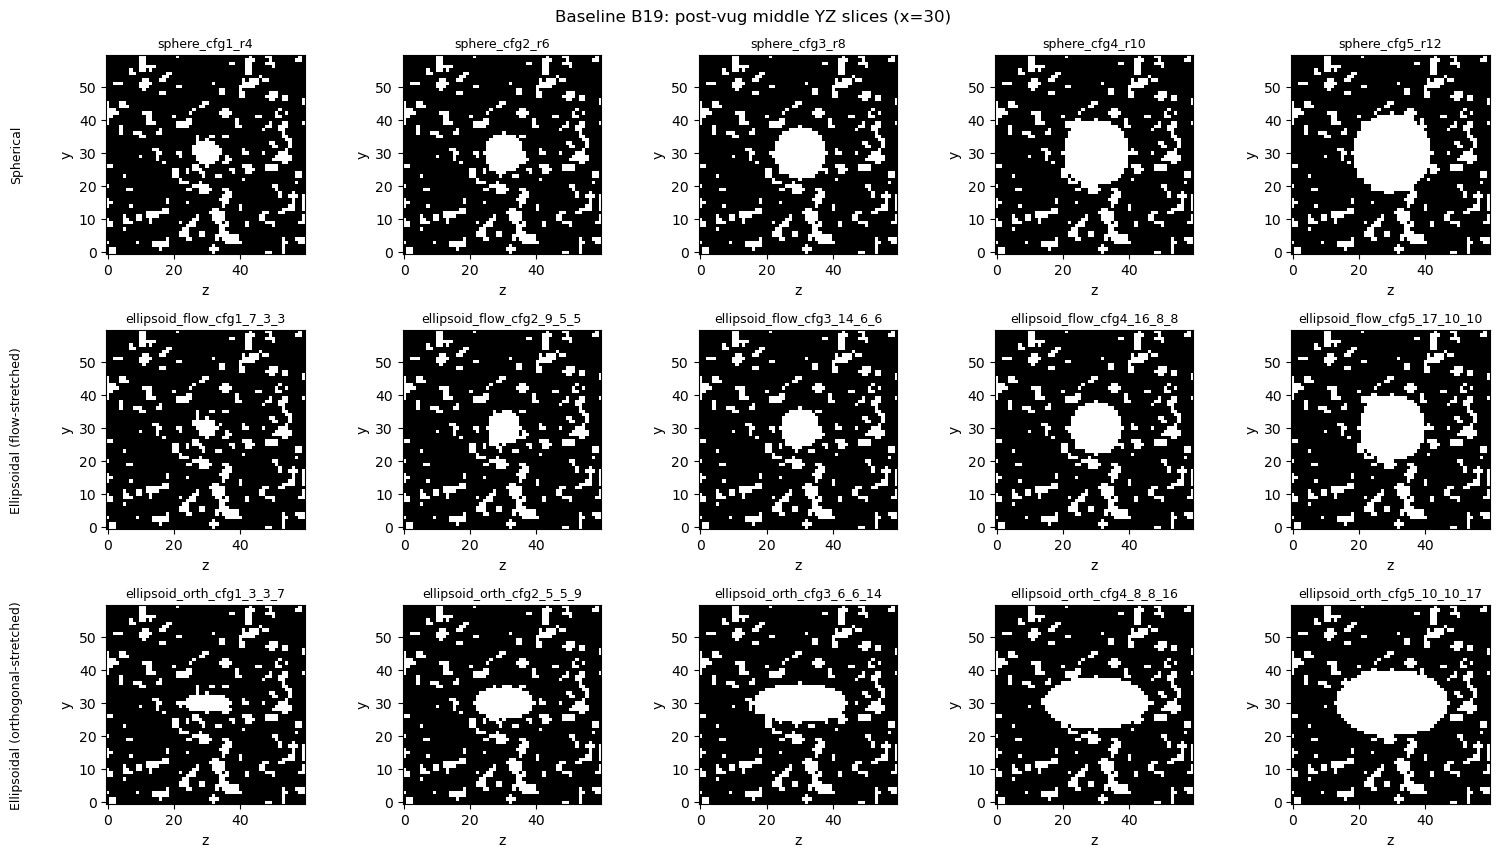

Plotting post-vug slice atlases:  63%|██████▎   | 19/30 [00:07<00:04,  2.56it/s]

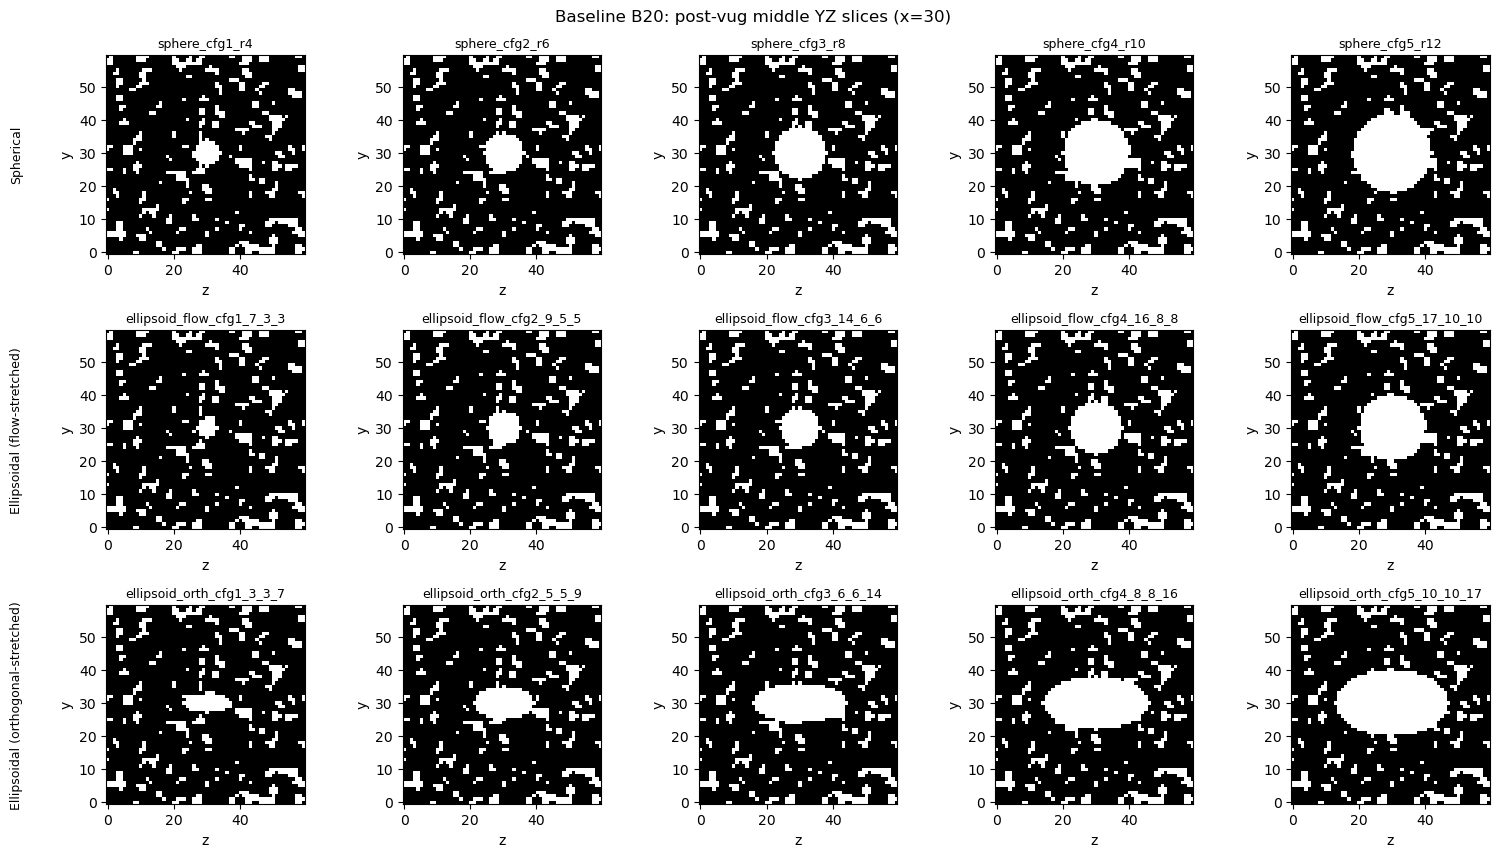

Plotting post-vug slice atlases:  67%|██████▋   | 20/30 [00:07<00:03,  2.55it/s]

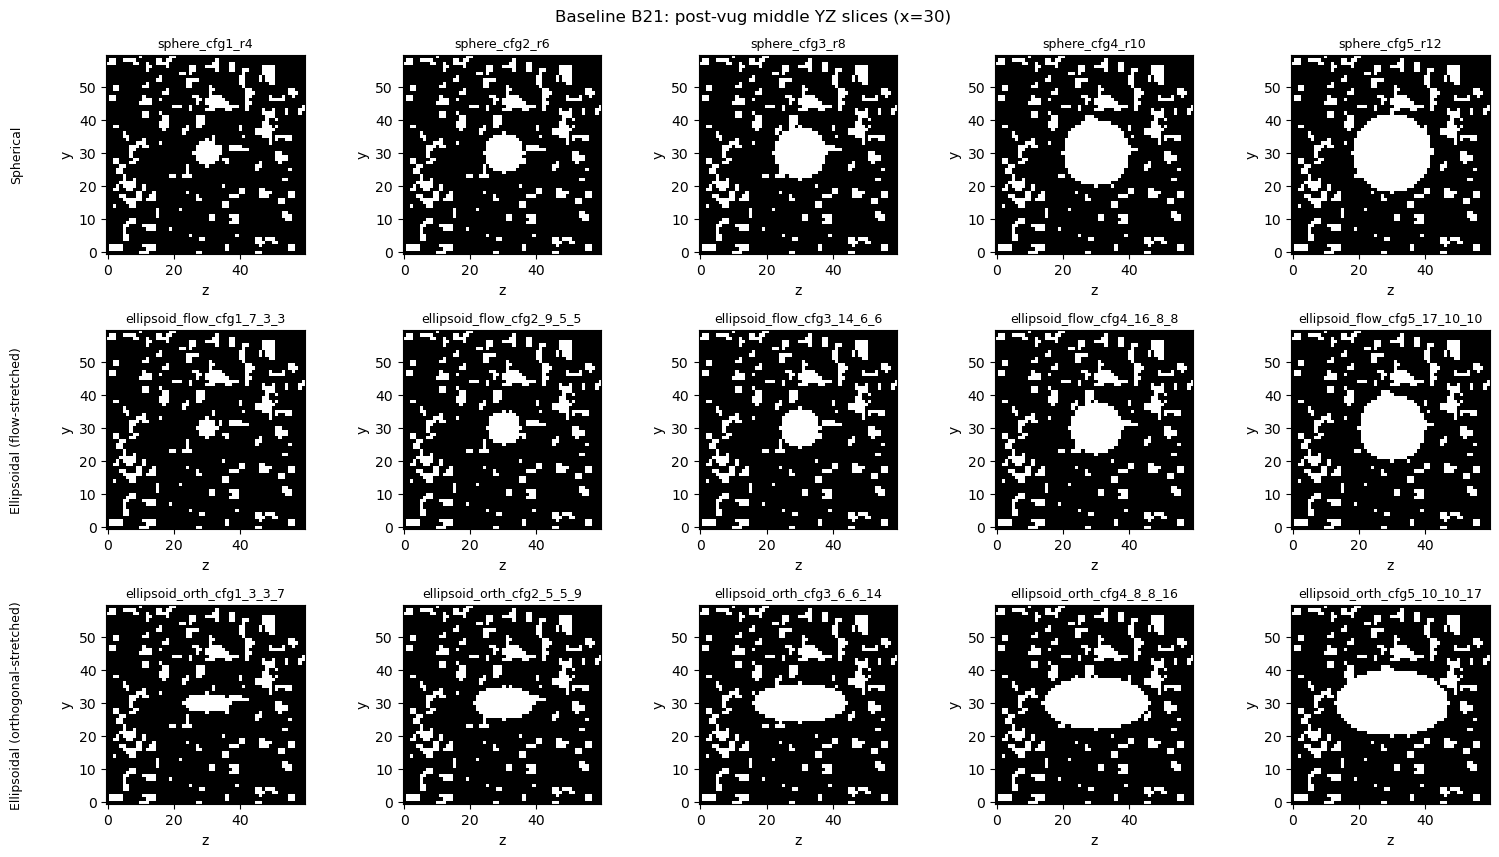

Plotting post-vug slice atlases:  70%|███████   | 21/30 [00:08<00:03,  2.49it/s]

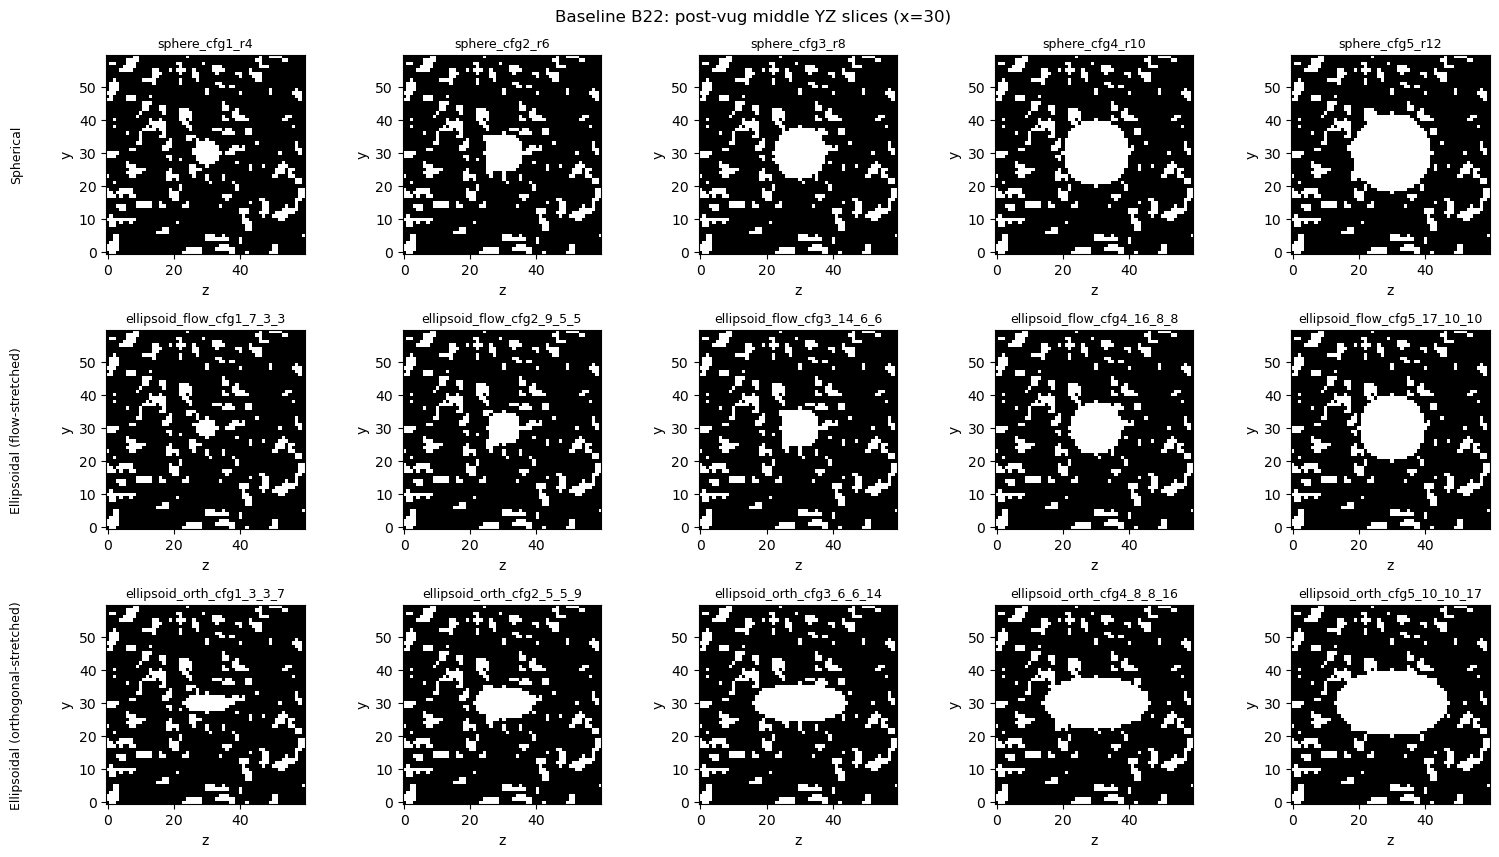

Plotting post-vug slice atlases:  73%|███████▎  | 22/30 [00:08<00:03,  2.48it/s]

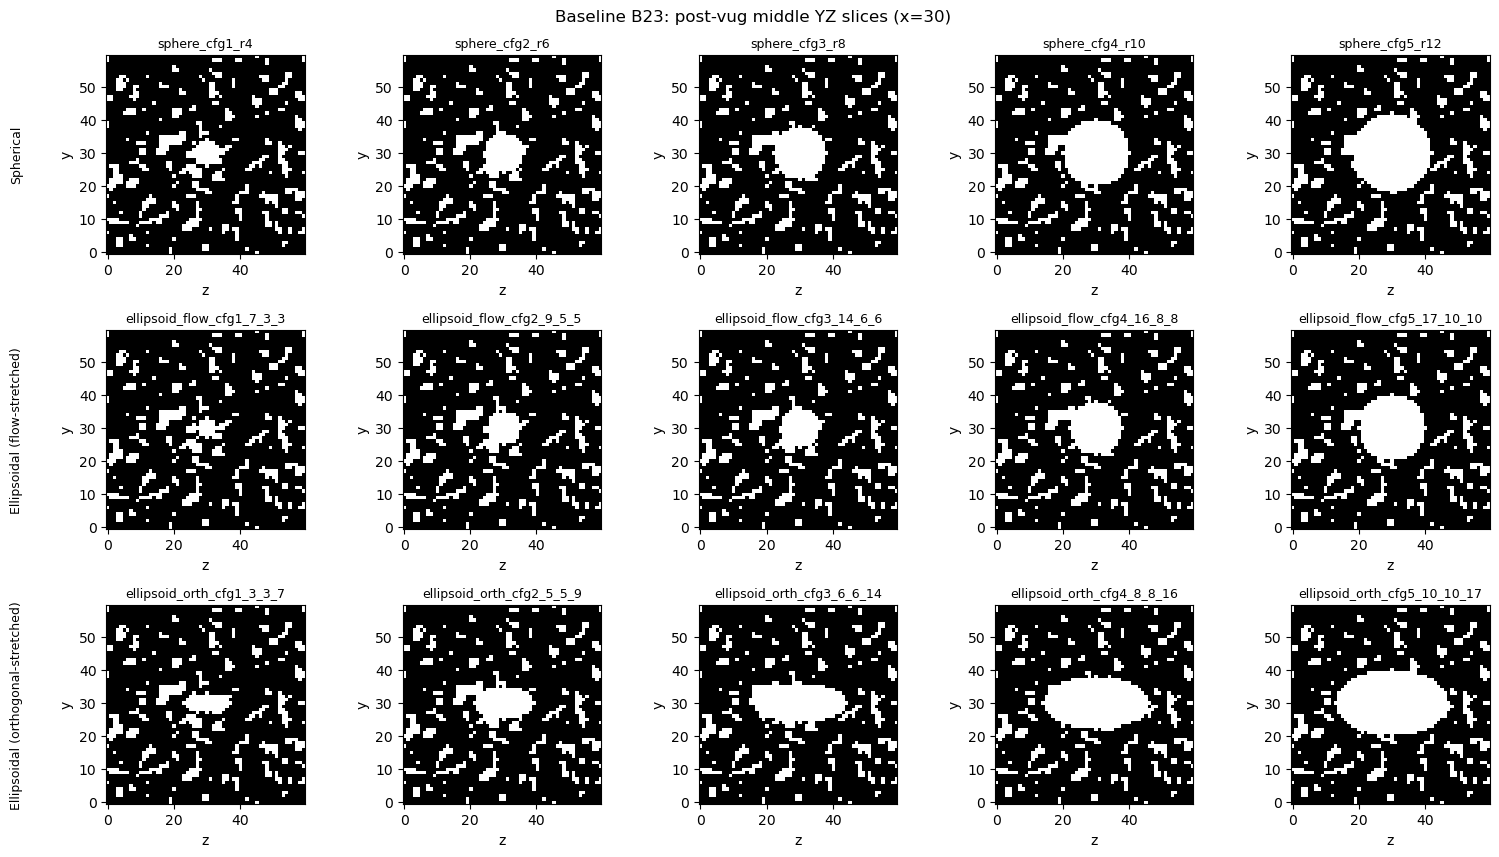

Plotting post-vug slice atlases:  77%|███████▋  | 23/30 [00:09<00:02,  2.49it/s]

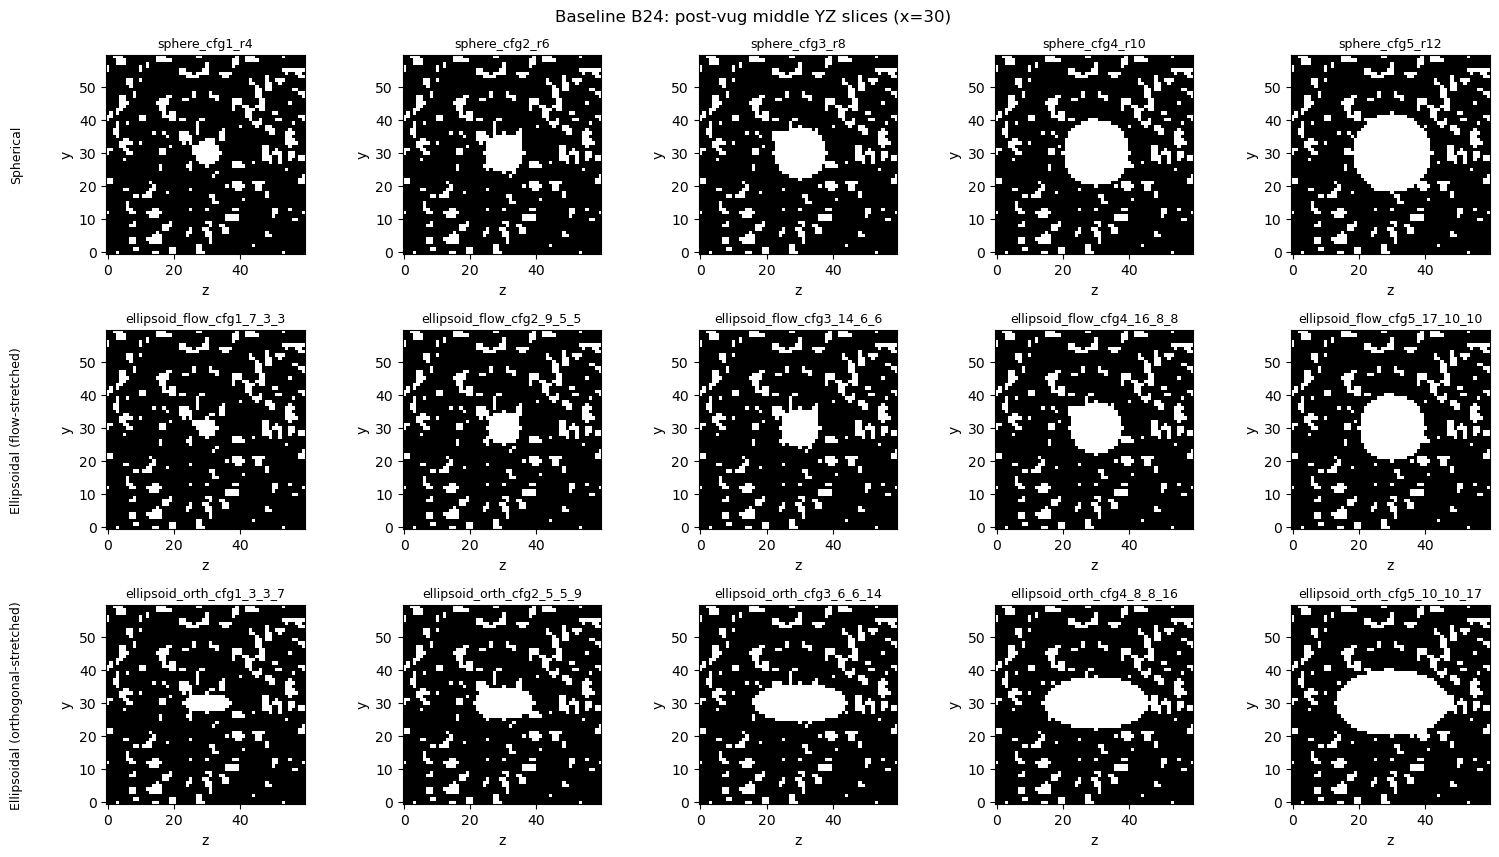

Plotting post-vug slice atlases:  80%|████████  | 24/30 [00:09<00:02,  2.51it/s]

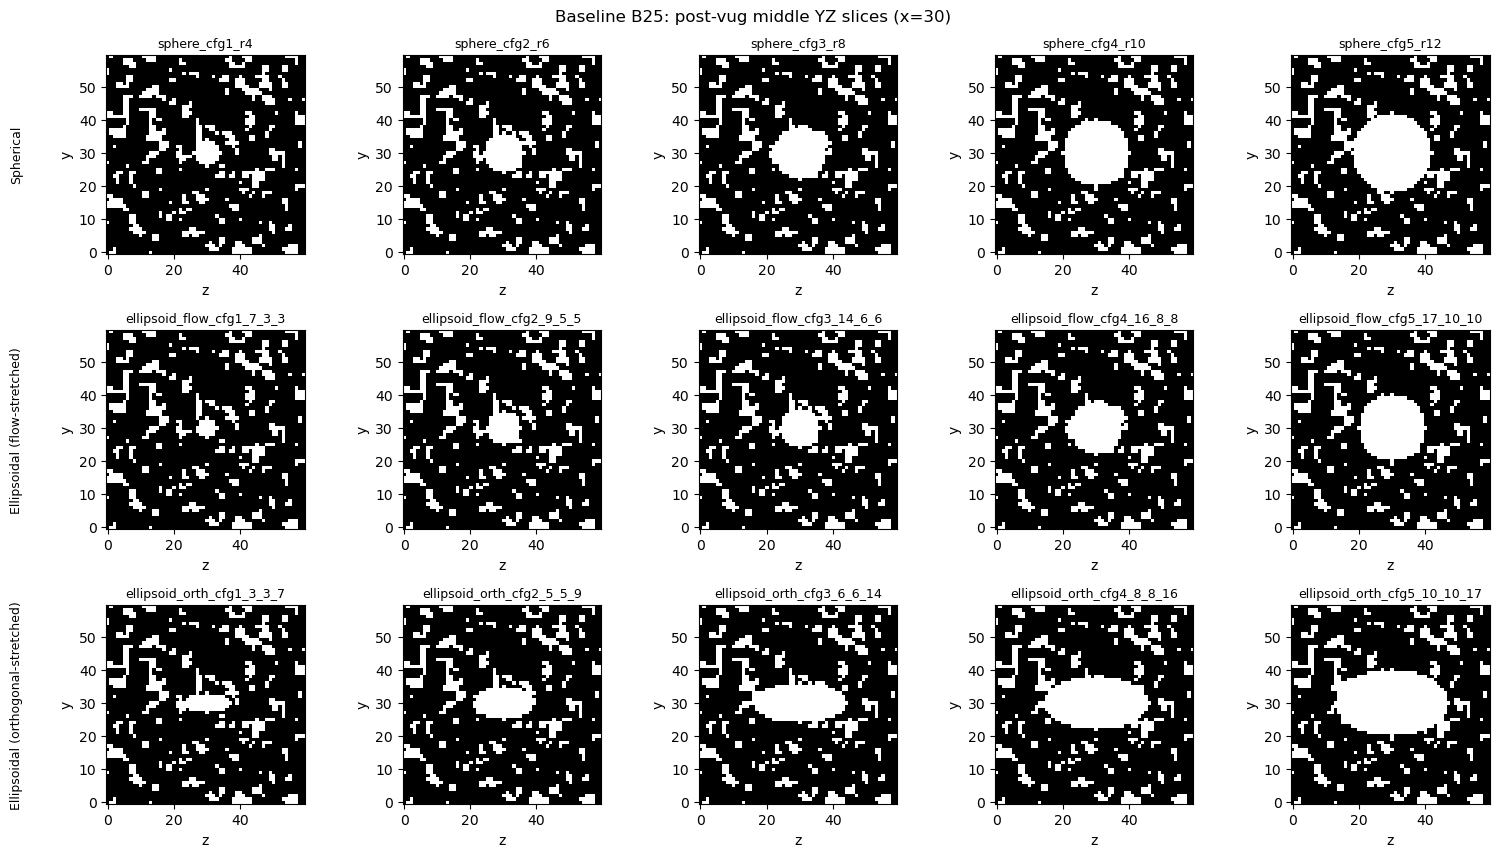

Plotting post-vug slice atlases:  83%|████████▎ | 25/30 [00:09<00:01,  2.53it/s]

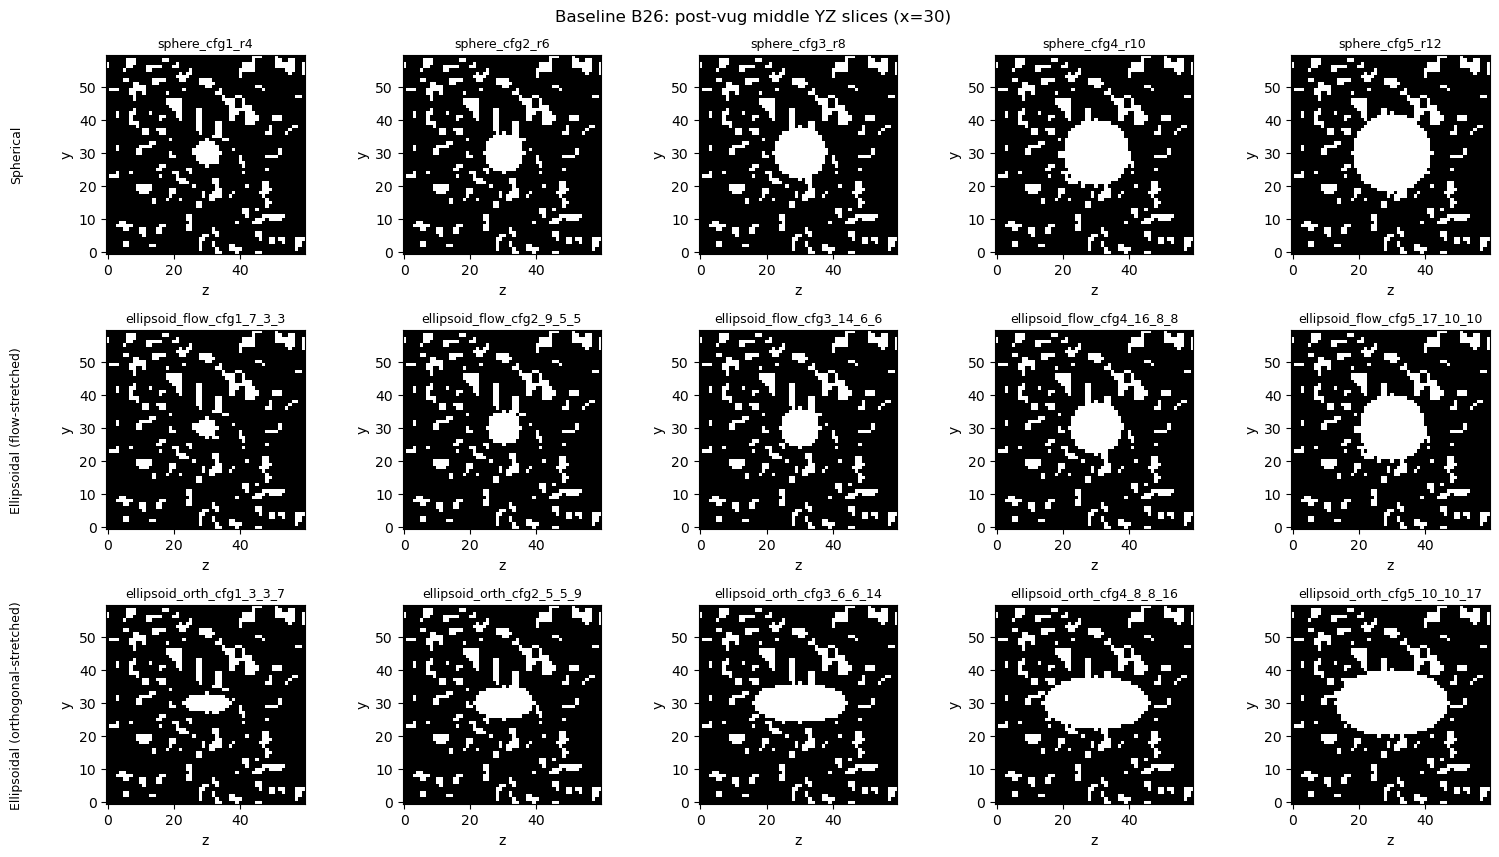

Plotting post-vug slice atlases:  87%|████████▋ | 26/30 [00:10<00:01,  2.55it/s]

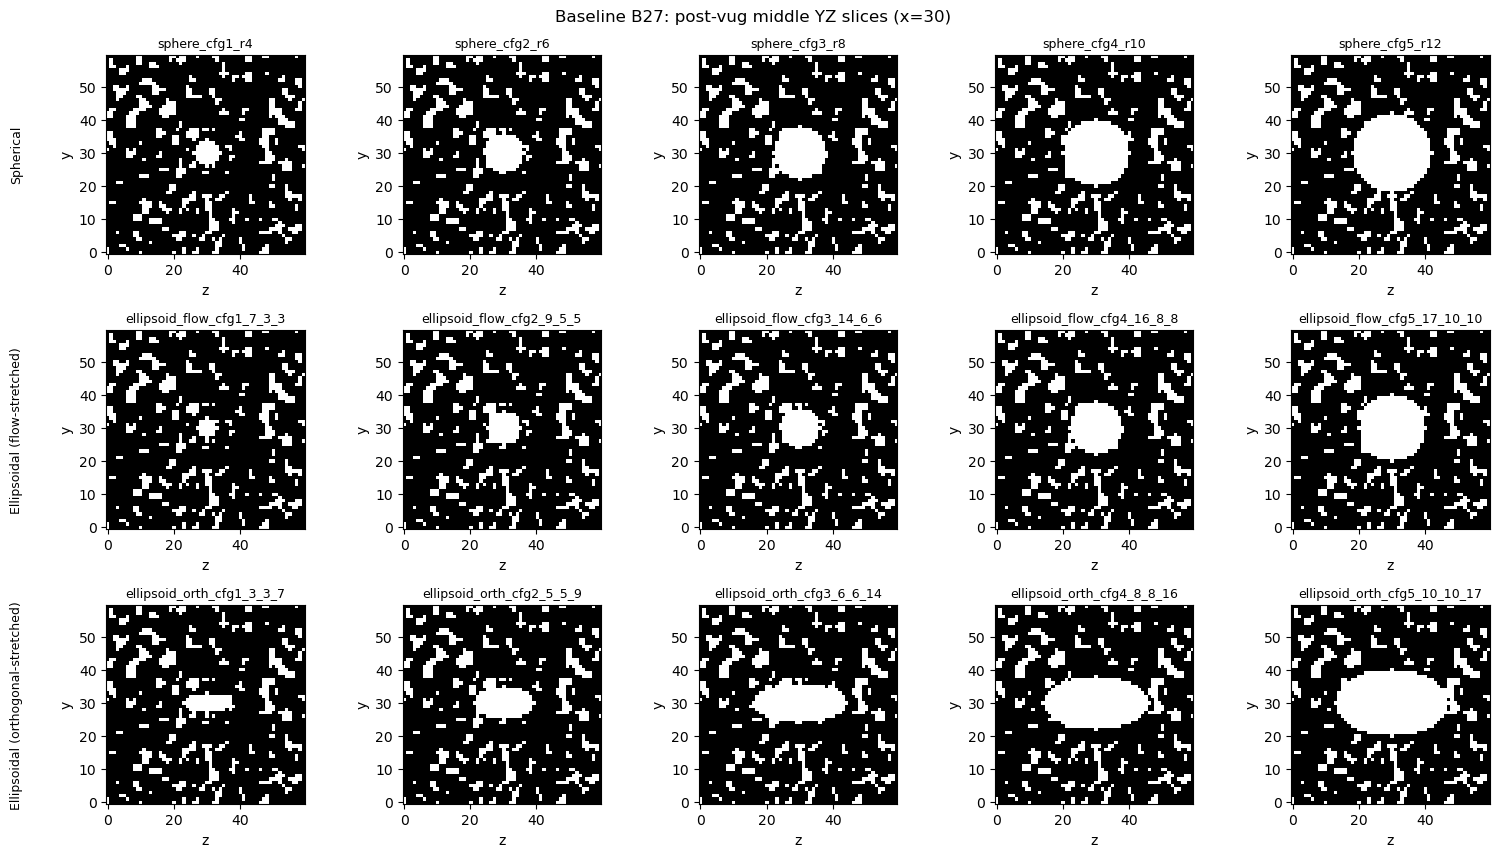

Plotting post-vug slice atlases:  90%|█████████ | 27/30 [00:10<00:01,  2.56it/s]

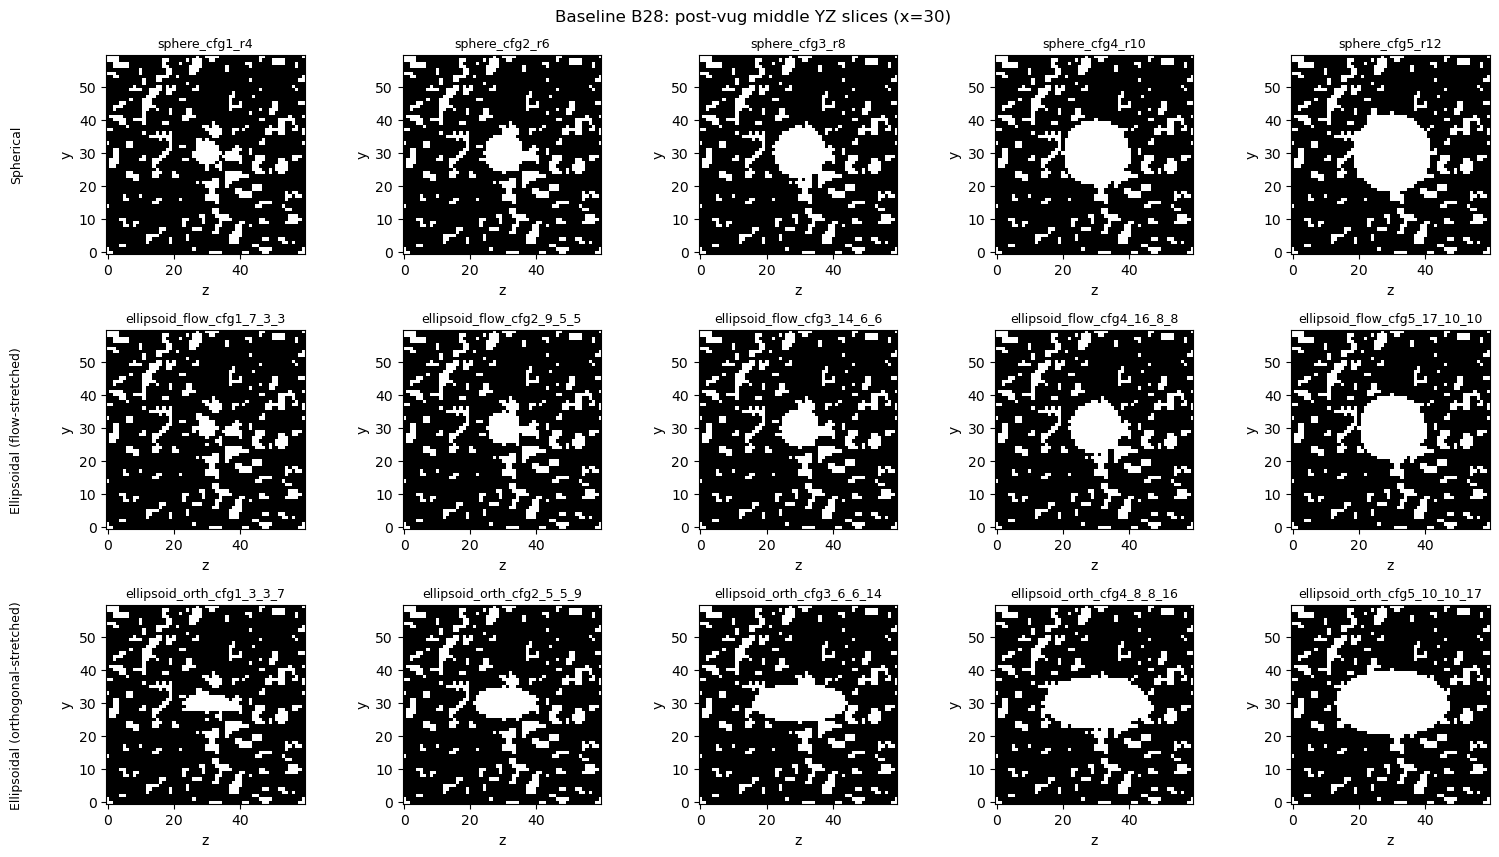

Plotting post-vug slice atlases:  93%|█████████▎| 28/30 [00:11<00:00,  2.53it/s]

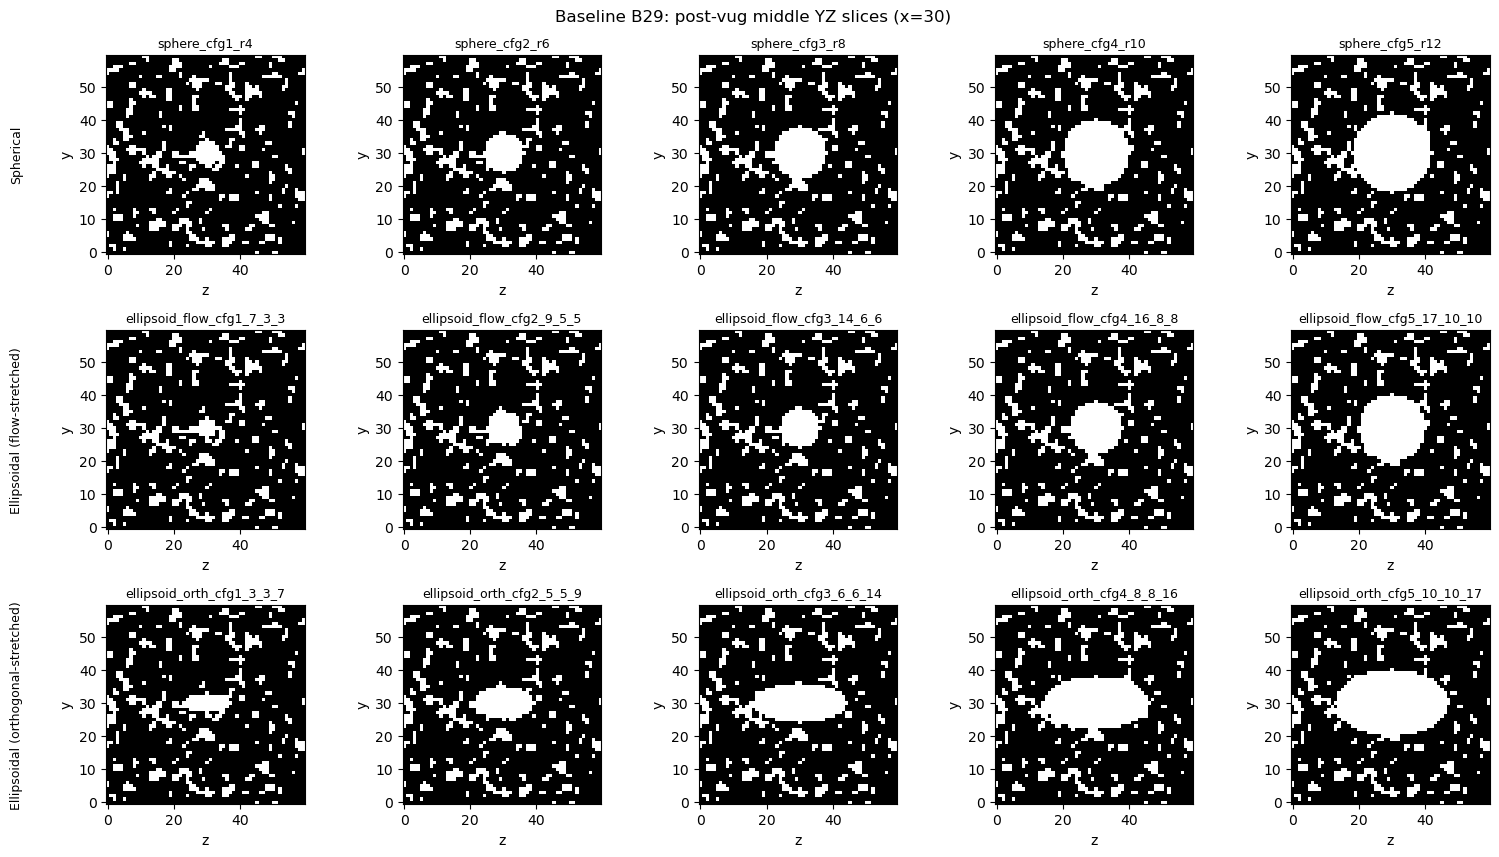

Plotting post-vug slice atlases:  97%|█████████▋| 29/30 [00:11<00:00,  2.54it/s]

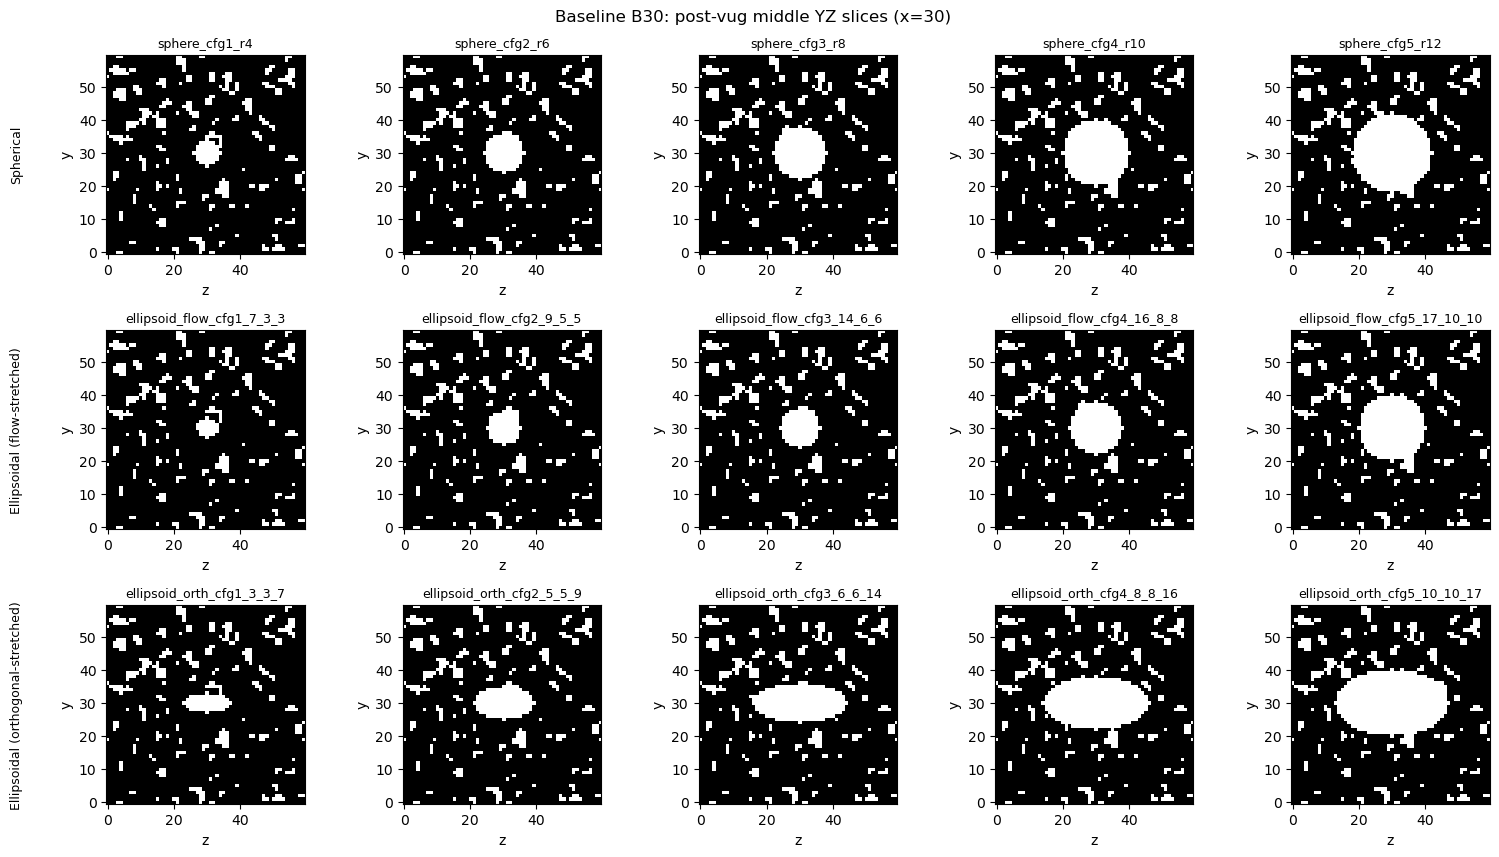

Plotting post-vug slice atlases: 100%|██████████| 30/30 [00:13<00:00,  2.24it/s]


In [52]:
templates_by_orientation = {
    "spherical": [t for t in vug_templates if t["orientation"] == "isotropic"],
    "flow_stretched": [
        t for t in vug_templates if t["orientation"] == "flow_stretched"
    ],
    "orthogonal_stretched": [
        t for t in vug_templates if t["orientation"] == "orthogonal_stretched"
    ],
}
orientation_order = ["spherical", "flow_stretched", "orthogonal_stretched"]
orientation_titles = {
    "spherical": "Spherical",
    "flow_stretched": "Ellipsoidal (flow-stretched)",
    "orthogonal_stretched": "Ellipsoidal (orthogonal-stretched)",
}

ncols_after = max(len(templates_by_orientation[key]) for key in orientation_order)
nrows_after = len(orientation_order)

for baseline_id in iter_progress(
    sorted(baseline_images.keys()),
    desc="Plotting post-vug slice atlases",
    total=len(baseline_images),
    enabled=USE_TQDM,
    leave=True,
):
    fig, axes = plt.subplots(
        nrows_after,
        ncols_after,
        figsize=(3.1 * ncols_after, 2.9 * nrows_after),
        squeeze=False,
    )
    for row_idx, orientation_key in enumerate(orientation_order):
        row_templates = templates_by_orientation[orientation_key]
        for col_idx in range(ncols_after):
            ax = axes[row_idx, col_idx]
            if col_idx >= len(row_templates):
                ax.axis("off")
                continue
            tpl = row_templates[col_idx]
            case_name = f"B{baseline_id}_{tpl['case']}"
            im = case_void_images[case_name]
            ax.imshow(im[mid_x], cmap="gray", origin="lower")
            ax.set_title(f"{tpl['case']}", fontsize=9)
            ax.set_xlabel("z")
            ax.set_ylabel("y")
            if col_idx == 0:
                ax.annotate(
                    orientation_titles[orientation_key],
                    xy=(-0.42, 0.5),
                    xycoords="axes fraction",
                    va="center",
                    ha="right",
                    fontsize=9,
                    rotation=90,
                )

    fig.suptitle(
        f"Baseline B{baseline_id}: post-vug middle YZ slices (x={mid_x})", fontsize=12
    )
    plt.tight_layout()
    plt.show()

## Aggregate response across baselines

For each vug template, we summarize mean ± std across the 15 baseline realizations.



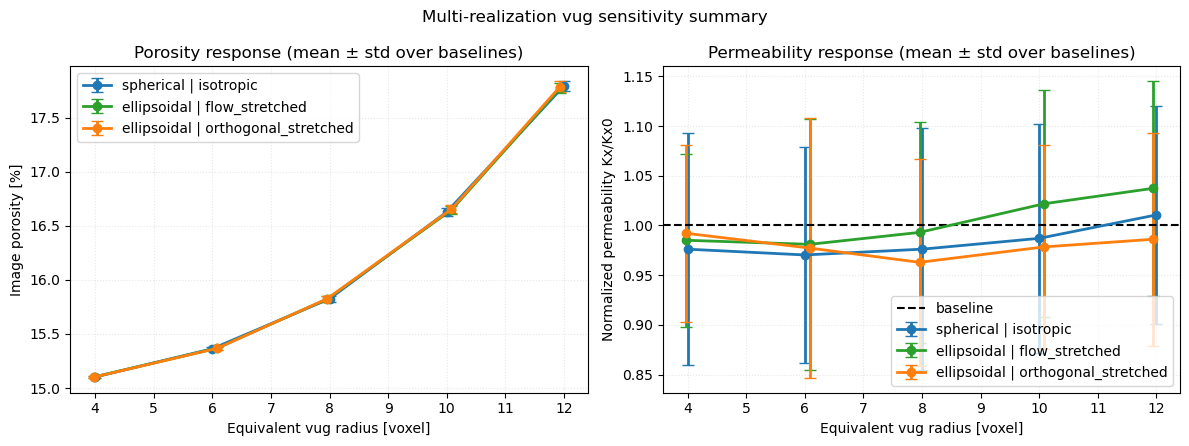

In [53]:
aggregated: dict[tuple[str, str, int], dict[str, object]] = {}
for row in all_results:
    family = str(row["family"])
    if family == "baseline":
        continue
    key = (family, str(row["orientation"]), int(row["config_index"]))
    if key not in aggregated:
        aggregated[key] = {
            "equivalent_radius_vox": float(row["equivalent_radius_vox"]),
            "k_ratio": [],
            "phi_image": [],
        }
    aggregated[key]["k_ratio"].append(float(row["K_ratio_to_baseline"]))
    aggregated[key]["phi_image"].append(float(row["phi_image"]))

orientation_groups = [
    ("spherical", "isotropic", "tab:blue"),
    ("ellipsoidal", "flow_stretched", "tab:green"),
    ("ellipsoidal", "orthogonal_stretched", "tab:orange"),
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for family, orientation, color in orientation_groups:
    keys = sorted(
        [k for k in aggregated if k[0] == family and k[1] == orientation],
        key=lambda k: k[2],
    )
    if not keys:
        continue
    r_eq = np.array([aggregated[k]["equivalent_radius_vox"] for k in keys], dtype=float)
    k_mean = np.array([np.mean(aggregated[k]["k_ratio"]) for k in keys], dtype=float)
    k_std = np.array([np.std(aggregated[k]["k_ratio"]) for k in keys], dtype=float)
    phi_mean = 100.0 * np.array(
        [np.mean(aggregated[k]["phi_image"]) for k in keys], dtype=float
    )
    phi_std = 100.0 * np.array(
        [np.std(aggregated[k]["phi_image"]) for k in keys], dtype=float
    )

    label = f"{family} | {orientation}"
    axes[0].errorbar(
        r_eq,
        phi_mean,
        yerr=phi_std,
        marker="o",
        linewidth=2,
        capsize=4,
        color=color,
        label=label,
    )
    axes[1].errorbar(
        r_eq,
        k_mean,
        yerr=k_std,
        marker="o",
        linewidth=2,
        capsize=4,
        color=color,
        label=label,
    )

axes[0].set_xlabel("Equivalent vug radius [voxel]")
axes[0].set_ylabel("Image porosity [%]")
axes[0].set_title("Porosity response (mean ± std over baselines)")
axes[0].grid(alpha=0.3, linestyle=":")
axes[0].legend()

axes[1].axhline(1.0, color="black", linestyle="--", linewidth=1.5, label="baseline")
axes[1].set_xlabel("Equivalent vug radius [voxel]")
axes[1].set_ylabel(f"Normalized permeability K{FLOW_AXIS}/K{FLOW_AXIS}0")
axes[1].set_title("Permeability response (mean ± std over baselines)")
axes[1].grid(alpha=0.3, linestyle=":")
axes[1].legend()

fig.suptitle("Multi-realization vug sensitivity summary")
plt.tight_layout()
plt.show()

## K/K0 Frequency Distributions By Equivalent Radius

For each equivalent vug radius, this section plots histograms of `K/K0`
distributions for the available vug configurations (across all baseline realizations).
Radii are grouped using a two-decimal rounding to avoid floating-point key noise.




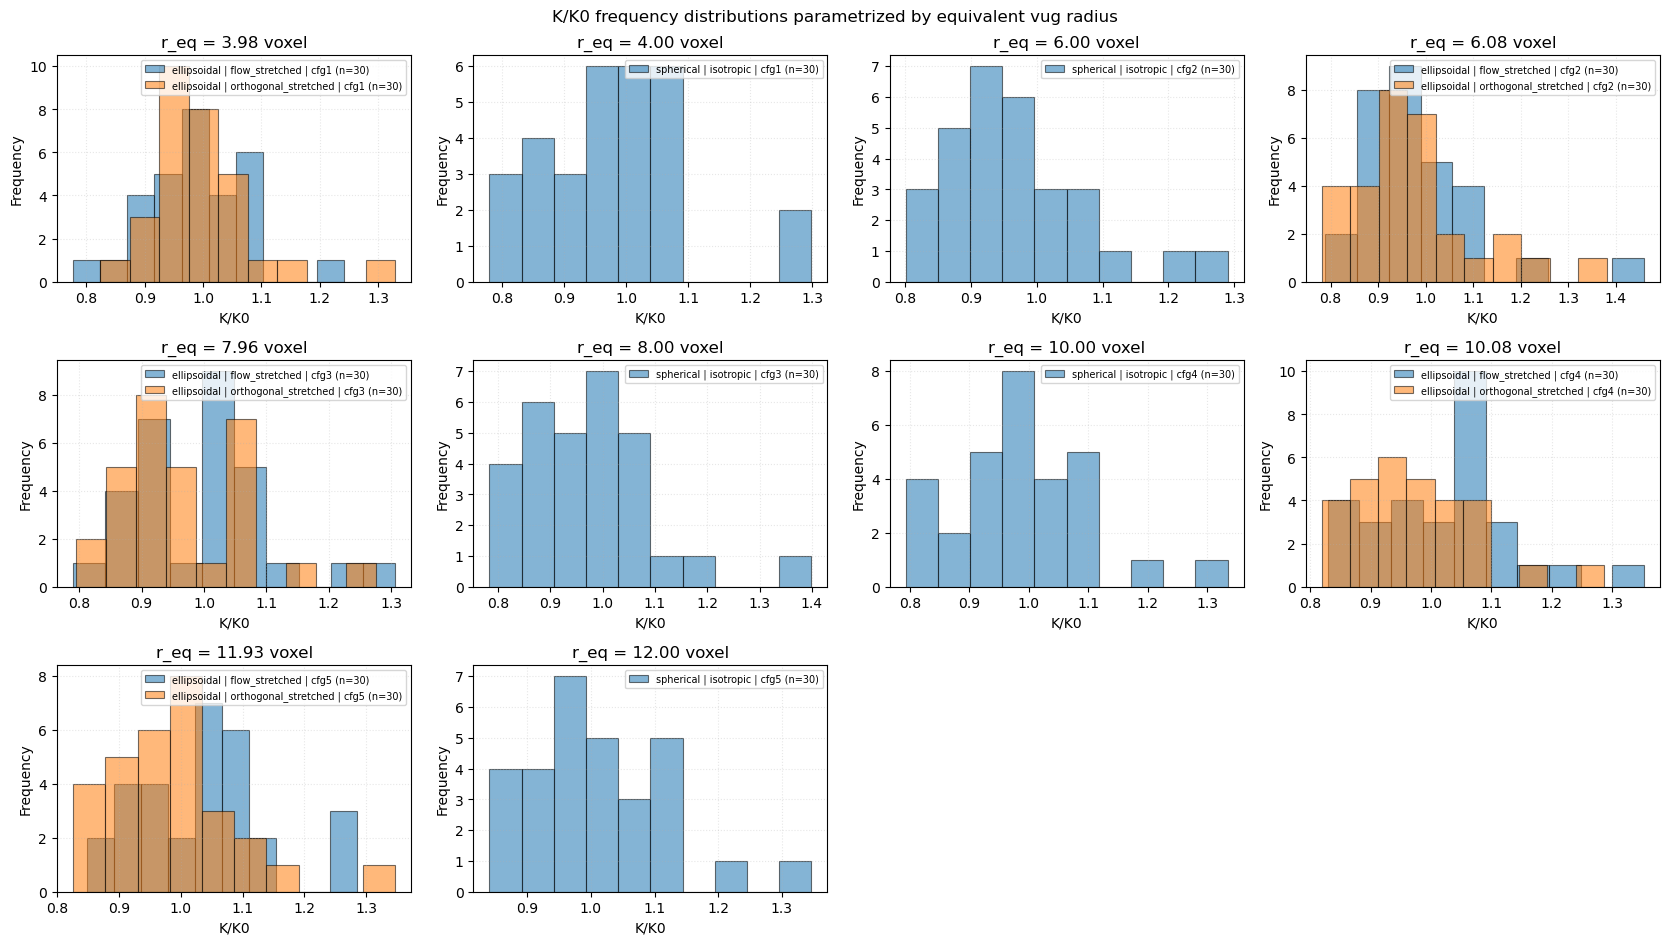

In [54]:
kk0_by_radius_and_config: dict[float, dict[str, list[float]]] = {}
for row in all_results:
    if str(row["family"]) == "baseline":
        continue
    radius_key = round(float(row["equivalent_radius_vox"]), 2)
    cfg_label = (
        f"{row['family']} | {row['orientation']} | cfg{int(row['config_index'])}"
    )
    if radius_key not in kk0_by_radius_and_config:
        kk0_by_radius_and_config[radius_key] = {}
    if cfg_label not in kk0_by_radius_and_config[radius_key]:
        kk0_by_radius_and_config[radius_key][cfg_label] = []
    kk0_by_radius_and_config[radius_key][cfg_label].append(
        float(row["K_ratio_to_baseline"])
    )

radius_keys = sorted(kk0_by_radius_and_config.keys())
ncols_hist = min(4, max(1, len(radius_keys)))
nrows_hist = (len(radius_keys) + ncols_hist - 1) // ncols_hist
fig, axes = plt.subplots(
    nrows_hist, ncols_hist, figsize=(4.2 * ncols_hist, 3.2 * nrows_hist), squeeze=False
)

for ax, radius_key in zip(axes.flat, radius_keys):
    cfg_map = kk0_by_radius_and_config[radius_key]
    for cfg_label, values in sorted(cfg_map.items()):
        vals = np.asarray(values, dtype=float)
        if vals.size == 0:
            continue
        if vals.size < 3 or np.allclose(vals, vals[0]):
            center = float(vals.mean())
            bins = np.array([center - 0.03, center + 0.03], dtype=float)
        else:
            bins = np.histogram_bin_edges(vals, bins=min(10, max(5, vals.size // 2)))
        ax.hist(
            vals,
            # bins=bins,
            alpha=0.55,
            edgecolor="black",
            linewidth=0.8,
            label=f"{cfg_label} (n={vals.size})",
        )
    ax.set_title(f"r_eq = {radius_key:.2f} voxel")
    ax.set_xlabel("K/K0")
    ax.set_ylabel("Frequency")
    ax.grid(alpha=0.3, linestyle=":")
    ax.legend(fontsize=7)

for ax in axes.flat[len(radius_keys) :]:
    ax.axis("off")

fig.suptitle("K/K0 frequency distributions parametrized by equivalent vug radius")
plt.tight_layout()
plt.show()

## Plotly pore-network visualization for all results

This cell displays the pore network with pressure coloring for **every solved case**.



In [55]:
print("Total Plotly figures:", len(all_diagnostics))
notebooks_env = os.environ.get("VOIDS_NOTEBOOKS_PATH")
if notebooks_env:
    notebooks_base = Path(notebooks_env).expanduser()
else:
    cwd = Path.cwd().resolve()
    repo_root = None
    for candidate in (cwd, *cwd.parents):
        if (candidate / "pixi.toml").exists() and (
            candidate / "src" / "voids"
        ).exists():
            repo_root = candidate
            break
    if repo_root is not None:
        notebooks_base = repo_root / "notebooks"
    else:
        notebooks_base = cwd
plotly_export_root = notebooks_base / "outputs/08_mwe_image_based_vug_shape_sensitivity"
plotly_html_dir = plotly_export_root / "plotly_html"
plotly_png_dir = plotly_export_root / "plotly_png"
plotly_html_dir.mkdir(parents=True, exist_ok=True)
plotly_png_dir.mkdir(parents=True, exist_ok=True)
print("Plotly HTML output:", plotly_html_dir)
print("PNG output:", plotly_png_dir)

png_export_summary = {"plotly_kaleido": 0, "matplotlib_fallback": 0, "failed": 0}

for case_name in iter_progress(
    sorted(all_diagnostics.keys()),
    desc="Exporting network visualizations",
    total=len(all_diagnostics),
    enabled=USE_TQDM,
    leave=True,
):
    fig = all_diagnostics[case_name]["plotly"]
    html_path = plotly_html_dir / f"{case_name}.html"
    png_path = plotly_png_dir / f"{case_name}.png"

    # Always save interactive HTML for later inspection.
    fig.write_html(html_path, include_plotlyjs="cdn")

    # Try static Plotly PNG first (requires kaleido), then fallback to Matplotlib snapshot.
    try:
        fig.write_image(png_path, format="png", scale=2)
        png_export_summary["plotly_kaleido"] += 1
    except Exception as _:
        try:
            save_network_png_matplotlib(
                net=all_diagnostics[case_name]["net"],
                pore_pressure=np.asarray(
                    all_diagnostics[case_name]["pore_pressure"], dtype=float
                ),
                png_path=png_path,
                title=str(all_diagnostics[case_name]["plotly_title"]),
                max_throats=PLOTLY_MAX_THROATS,
            )
            png_export_summary["matplotlib_fallback"] += 1
        except Exception as exc2:
            png_export_summary["failed"] += 1
            print(f"Failed to save PNG for {case_name}: {exc2}")

print("PNG export summary:", png_export_summary)

Total Plotly figures: 480
Plotly HTML output: /Users/dtvolpatto/Work/voids/notebooks/outputs/08_mwe_image_based_vug_shape_sensitivity/plotly_html
PNG output: /Users/dtvolpatto/Work/voids/notebooks/outputs/08_mwe_image_based_vug_shape_sensitivity/plotly_png


Exporting network visualizations: 100%|██████████| 480/480 [04:38<00:00,  1.73it/s]

PNG export summary: {'plotly_kaleido': 0, 'matplotlib_fallback': 480, 'failed': 0}


## Interpretation and caveats

Observations to verify in your run:

- Adding vugs increases porosity in all baseline realizations.
- `Kabs` response is generally non-monotonic at case level and depends on connectivity
  reorganization after extraction, not only on added void volume.
- For similar equivalent radius, ellipsoid orientation (flow-stretched vs orthogonal)
  can produce different transport responses.

Potentially incorrect assumptions or limitations:

- One centered vug does not capture stochastic spatial distributions of vugs.
- Synthetic grayscale + Otsu may differ from real imaging artifacts and segmentation bias.
- Results depend on the extraction model (`snow2`) and conductance model
  (`valvatne_blunt_baseline`).
- Even with 15 baselines, uncertainty quantification is still limited; more realizations
  are recommended for robust inference.
